# Big Mart Sales Prediction

**📚 Dataset 📚**

[Big Mart Sales](https://www.kaggle.com/datasets/mrmorj/big-mart-sales)

Owner of the Dataset (@ Kaggle):

* *Andrii Samoshyn*

**💬 Dataset's Description 💬**

The data scientists at BigMart have collected 2013 sales data for 1559 products across 10 stores in different cities. Also, certain attributes of each product and store have been defined. The aim is to build a predictive model and predict the sales of each product at a particular outlet.

**🧐 Features Information 🧐**

* **Item_Identifier**: Unique product ID
* **Item_Weight**: Weight of product
* **Item_Fat_Content**: Whether the product is low fat or not
* **Item_Visibility**: The % of total display area of all products in a store allocated to the particular product
* **Item_Type**: The category to which the product belongs
* **Item_MRP**: Maximum Retail Price (list price) of the product
* **Outlet_Identifier**: Unique store ID
* **Outlet_Establishment_Year**: The year in which store was established
* **Outlet_Size** The size of the store in terms of ground area covered
* **Outlet_Location_Type**: The type of city in which the store is located
* **Outlet_Type**: Whether the outlet is just a grocery store or some sort of supermarket
* **Item_Outlet_Sales**: Sales of the product in the particular store. This is the outcome variable to be predicted.

**📌 Target Feature 📌**

* **Item_Outlet_Sales**

## 🔍 Exploratory Data Analysis (EDA)

### <center> Problem & Data Understanding

ini isinya

### <center> Data Loading & General Inspection

In [1]:
# Import basic need library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warnings to get clean output
warnings.filterwarnings('ignore')

# Set pandas to display all features
pd.set_option('display.max_columns', None)

# Set pandas to display all rows
# pd.set_option('display.max_rows', None)

# Loading Dataset
df = pd.read_csv("https://raw.githubusercontent.com/fathirrizki/learn-Python/refs/heads/main/playgrounds/datasets/big_mart_sales.csv")

# Showing top 5 row on the Dataset
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [2]:
# Showing last 5 row on the Dataset
df.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [3]:
#  Dataset's dimension
df.shape

(8523, 12)

In [4]:
# Dataset's general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
# All variable statistic description
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,8523,1559,FDW13,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,7060.0,NaN,NaN,NaN,12.857645,4.643456,4.555,8.77375,12.6,16.85,21.35
Item_Fat_Content,8523,5,Low Fat,5089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,8523.0,NaN,NaN,NaN,0.066132,0.051598,0.0,0.026989,0.053931,0.094585,0.328391
Item_Type,8523,16,Fruits and Vegetables,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,8523.0,NaN,NaN,NaN,140.992782,62.275067,31.29,93.8265,143.0128,185.6437,266.8884
Outlet_Identifier,8523,10,OUT027,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,8523.0,NaN,NaN,NaN,1997.831867,8.37176,1985.0,1987.0,1999.0,2004.0,2009.0
Outlet_Size,6113,3,Medium,2793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,8523,3,Tier 3,3350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# All categorical feature value
categorical_feature = df.select_dtypes(include='object')

for feature in categorical_feature:
    print(f'{df[feature].value_counts()}\n')

Item_Identifier
FDW13    10
FDG33    10
NCF42     9
FDW26     9
FDX31     9
         ..
FDY43     1
FDO33     1
FDK57     1
FDQ60     1
FDN52     1
Name: count, Length: 1559, dtype: int64

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count,

### <center> Explore Data Characteristics

In [7]:
# Choosing color palettes
sns.set_palette('tab10')

# Make a copy of dataset, keep the original untouched
df_eda = df.copy()

In [8]:
# Before continue, we aware that feature 'Item_Fat_Content' contains unstructured categories:
# 'LF' and 'low fat' has the same meaning as 'Low Fat', 'reg' has the same meaning as 'Regular'
# We will structure it first before we visualize

# Before
print(f'Before structuring:\n{'='*19}\n{df_eda['Item_Fat_Content'].value_counts()}\n')

# Structuring
df_eda['Item_Fat_Content'] = df_eda['Item_Fat_Content'].replace(['LF', 'low fat'], 'Low Fat')
df_eda['Item_Fat_Content'] = df_eda['Item_Fat_Content'].replace('reg', 'Regular')

# After
print(f'After structuring:\n{'='*19}\n{df_eda['Item_Fat_Content'].value_counts()}')

Before structuring:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

After structuring:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


#### <center> Identify Missing Values, Duplicates, & Outliers

In [9]:
# Is there any missing value in the dataset?
print(f'Missing value:\n{'='*14}\n{df_eda.isnull().sum()}')

Missing value:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [10]:
# Check Missing value percentages
print(f'Missing value percentages for every features:\n{'='*45}\n{df_eda.isnull().mean() * 100}')

# 'Item_Weight' we will apply smart imputation
# 'Outlet_Size' we still searching for the answer

Missing value percentages for every features:
Item_Identifier               0.000000
Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64


In [11]:
# Display Rows that containt a Null in Any Column
df_eda[df_eda.isnull().any(axis=1)]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.20,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.20,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350
18,DRI11,NaN,Low Fat,0.034238,Hard Drinks,113.2834,OUT027,1985,Medium,Tier 3,Supermarket Type3,2303.6680
...,...,...,...,...,...,...,...,...,...,...,...,...
8504,NCN18,NaN,Low Fat,0.124111,Household,111.7544,OUT027,1985,Medium,Tier 3,Supermarket Type3,4138.6128
8508,FDW31,11.35,Regular,0.043246,Fruits and Vegetables,199.4742,OUT045,2002,NaN,Tier 2,Supermarket Type1,2587.9646
8509,FDG45,8.10,Low Fat,0.214306,Fruits and Vegetables,213.9902,OUT010,1998,NaN,Tier 3,Grocery Store,424.7804
8514,FDA01,15.00,Regular,0.054489,Canned,57.5904,OUT045,2002,NaN,Tier 2,Supermarket Type1,468.7232


In [12]:
# Is there any duplicate value in the dataset?
print(f'Total of duplicate row: {df_eda.duplicated().sum()}')

Total of duplicate row: 0


In [13]:
# Is there any outliers in the dataset? (by IQR)
numerical_feature = df_eda.select_dtypes(include=['int64', 'float64'])

for feature in numerical_feature:
    # Calculate the IQR
    q1 = df_eda[feature].quantile(0.25)
    q3 = df_eda[feature].quantile(0.75)
    iqr = q3 - q1

    # Set the bound
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    # Check the Outliers
    outliers = df_eda[(df_eda[feature] < lower_bound) | (df_eda[feature] > upper_bound)]
    print(f'[{feature}] total outliers: {len(outliers)}')
    print(f'[{feature}] total outliers (percentage): {(len(outliers)/df_eda.shape[0]) * 100:.2f}%\n')

# There are outliers on `Item_Visibility` and `Item_Outlet_Sales`
# We will try to transform it on Data Preprocessing and Model Training phase

[Item_Weight] total outliers: 0
[Item_Weight] total outliers (percentage): 0.00%

[Item_Visibility] total outliers: 144
[Item_Visibility] total outliers (percentage): 1.69%

[Item_MRP] total outliers: 0
[Item_MRP] total outliers (percentage): 0.00%

[Outlet_Establishment_Year] total outliers: 0
[Outlet_Establishment_Year] total outliers (percentage): 0.00%

[Item_Outlet_Sales] total outliers: 186
[Item_Outlet_Sales] total outliers (percentage): 2.18%



#### <center> Univariate Analysis
##### <center> Numerical Features

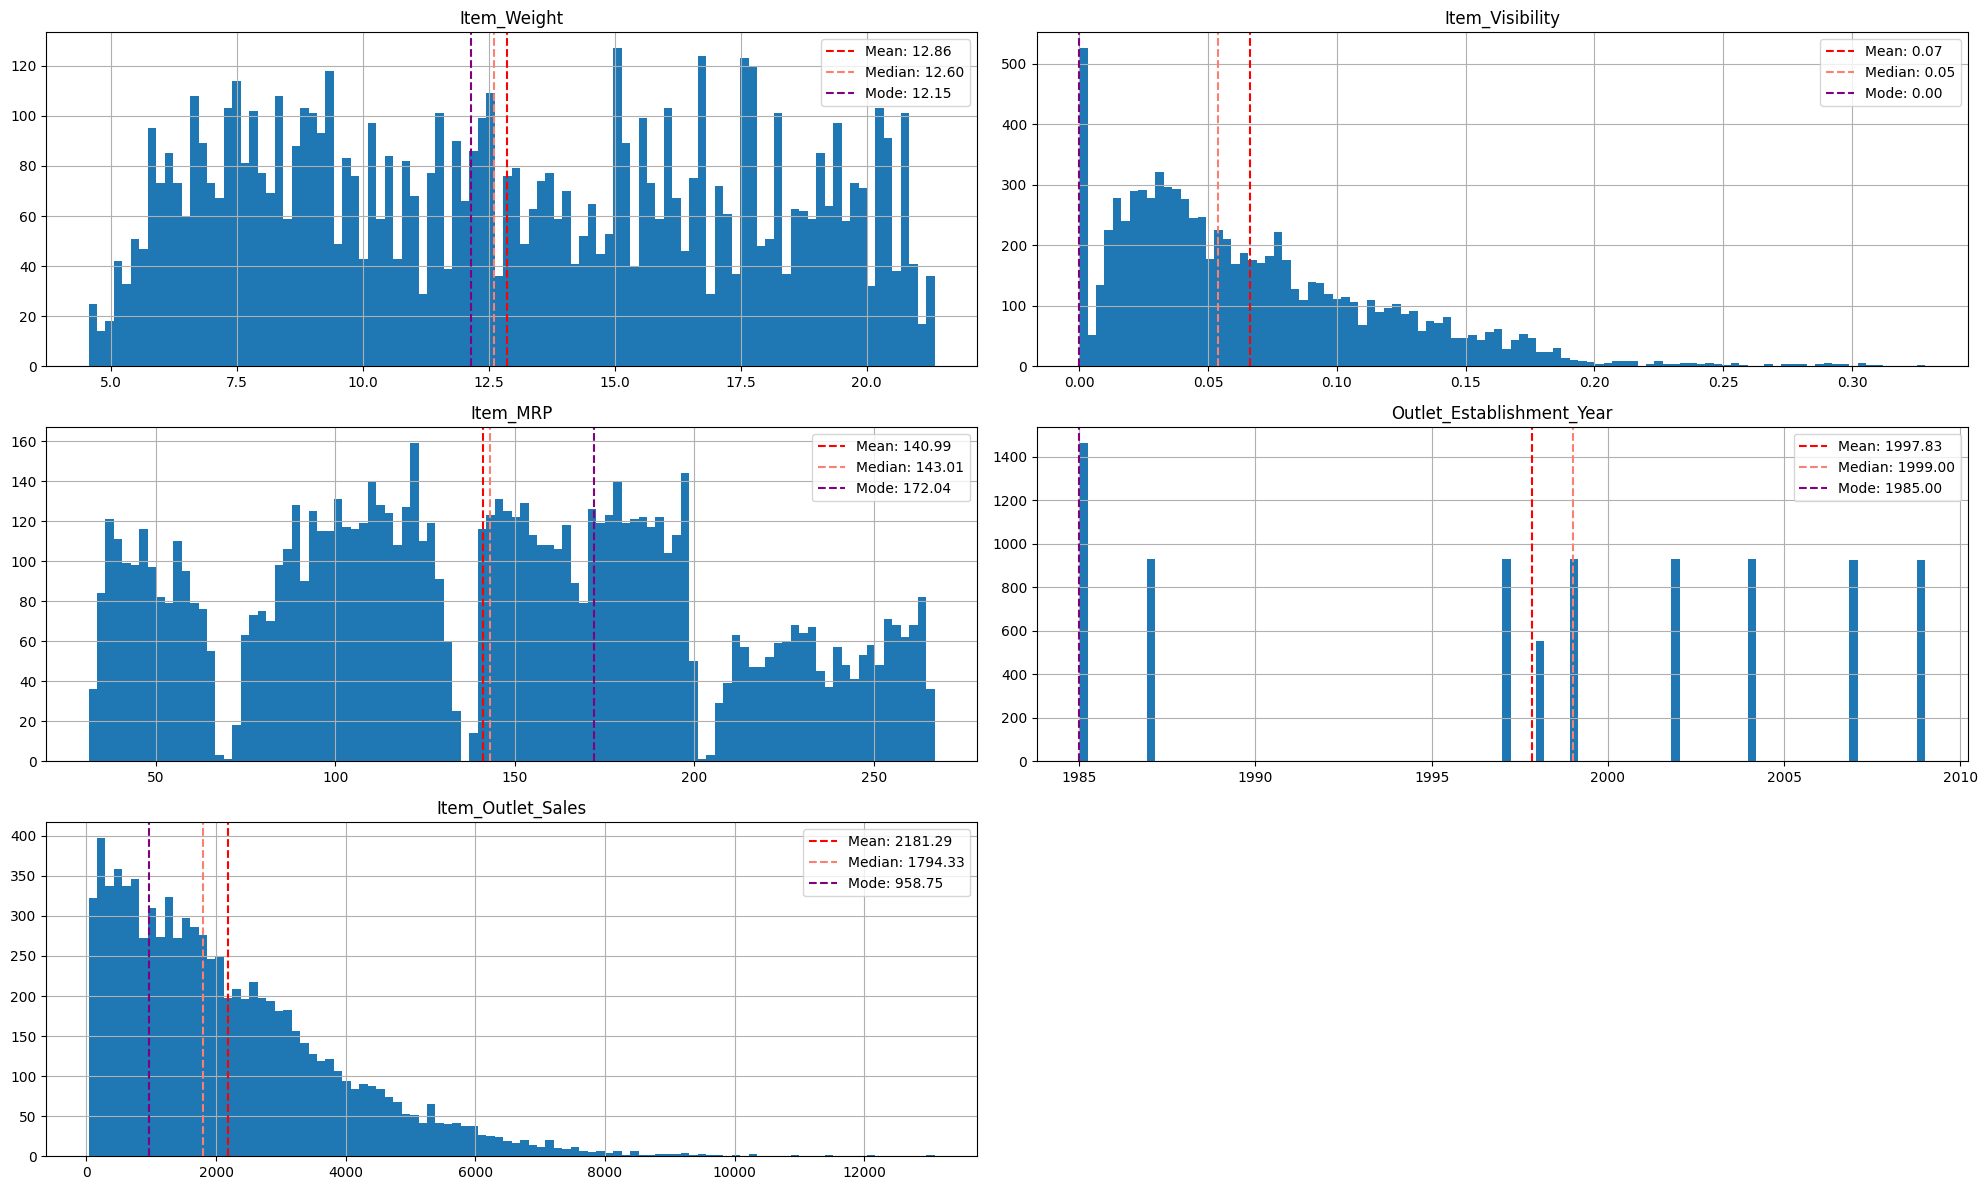

In [14]:
# All numeric (int, float) histograms
axes = df_eda.hist(bins=100, figsize=(20, 12))

# Create histogram
for row_axes in axes:
    for ax in row_axes:
        # Calculate the mean, median, mode
        feature_name = ax.get_title()
        if feature_name in df_eda.columns:
            mean_val = df_eda[feature_name].mean()
            median_val = df_eda[feature_name].median()
            mode_val = df_eda[feature_name].mode()[0]

            # Add vertical line to highlight the mean
            ax.axvline(
                mean_val,
                color='red',
                linestyle='--',
                linewidth=1.5,
                label=f'Mean: {mean_val:.2f}'
            )

            # Add vertical line to highlight the median
            ax.axvline(
                median_val,
                color='salmon',
                linestyle='--',
                linewidth=1.5,
                label=f'Median: {median_val:.2f}'
            )

            # Add vertical line to highlight the mode
            ax.axvline(
                mode_val,
                color='purple',
                linestyle='--',
                linewidth=1.5,
                label=f'Mode: {mode_val:.2f}'
            )
            ax.legend()

plt.tight_layout()
plt.show()

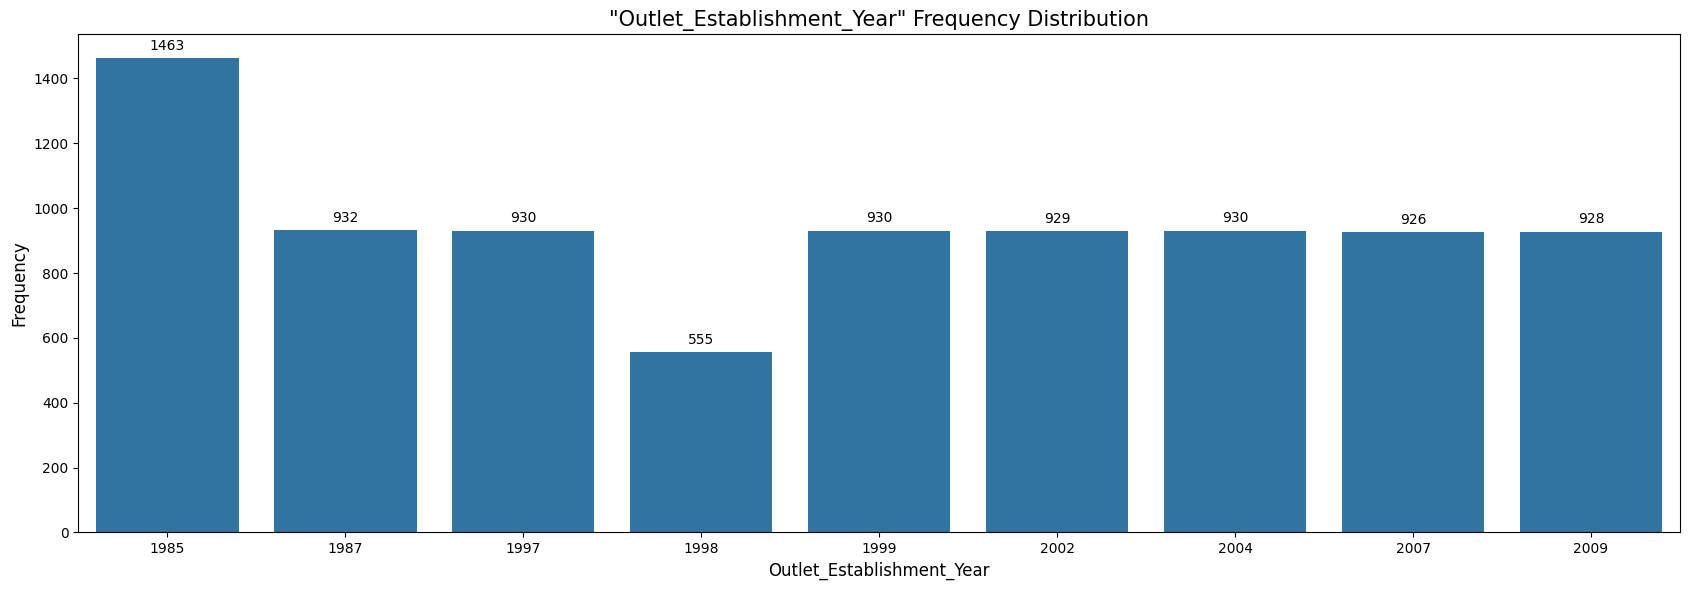

In [15]:
# Create bar chart for numerical discrete feature
discrete_feature = 'Outlet_Establishment_Year'

# Create subplot grid 1x1
fig, ax = plt.subplots(figsize=(17,6))

# Create bar chart
sns.countplot(x=discrete_feature, data=df_eda, ax=ax)
ax.set_title(f'"{discrete_feature}" Frequency Distribution', fontsize=15)
ax.set_xlabel(discrete_feature, fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Add total label in every bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha = 'center', va = 'center',
            xytext = (0, 9),
            textcoords = 'offset points')

plt.tight_layout()
plt.show()

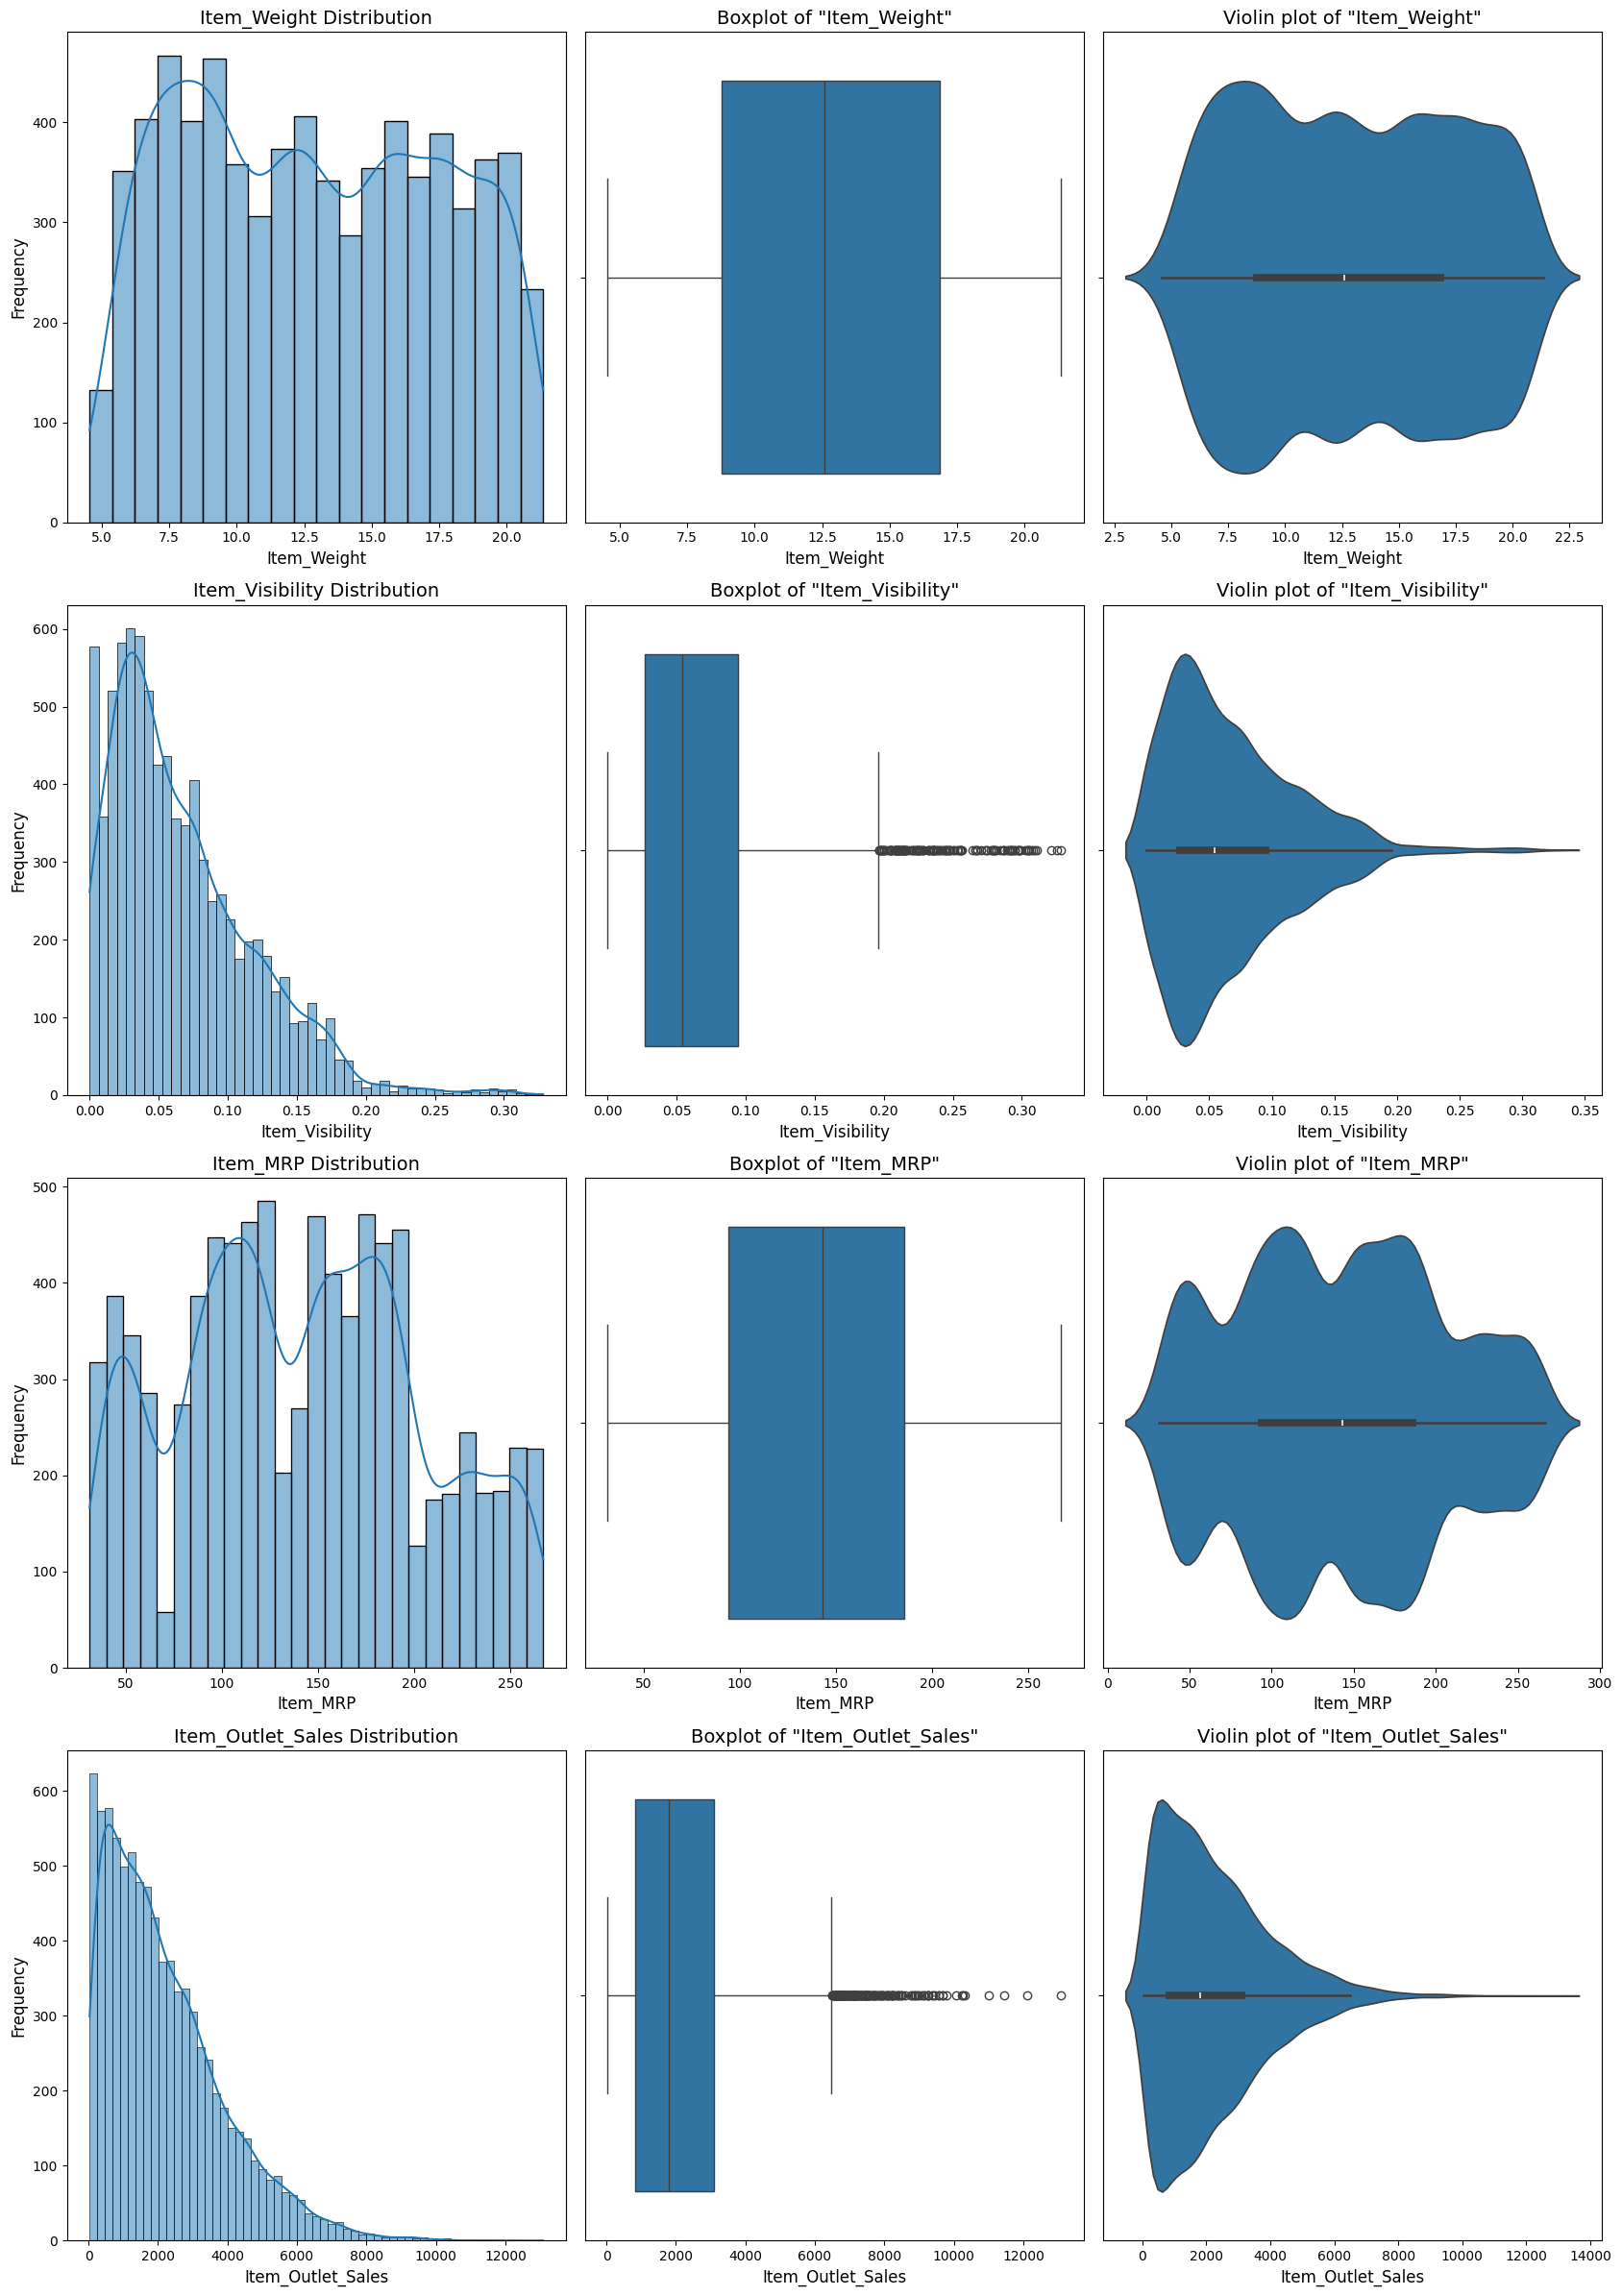

In [16]:
# Create numerical continue feature distribution visualization
continue_feature = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']

# Create subplot grid
fig, axes = plt.subplots(len(continue_feature), 3, figsize=(17,len(continue_feature)*6))

# Create visualization for every features
for ax, feature in enumerate(continue_feature):
    # Histogram
    sns.histplot(data=df_eda, x=feature , kde=True, ax=axes[ax, 0])
    axes[ax, 0].set_title(f'{feature} Distribution', fontsize=14)
    axes[ax, 0].set_xlabel(feature, fontsize=12)
    axes[ax, 0].set_ylabel('Frequency', fontsize=12)

    # Boxplot
    sns.boxplot(data=df_eda, x=feature, ax=axes[ax, 1])
    axes[ax, 1].set_title(f'Boxplot of "{feature}"', fontsize=14)
    axes[ax, 1].set_xlabel(feature, fontsize=12)

    # Violin plot
    sns.violinplot(data=df_eda, x=feature, ax=axes[ax, 2])
    axes[ax, 2].set_title(f'Violin plot of "{feature}"', fontsize=14)
    axes[ax, 2].set_xlabel(feature, fontsize=12)

plt.tight_layout()
plt.show()

##### <center> Categorical Features

In [17]:
# Check what categorical features that able to be visualized
categorical_feature = df_eda.select_dtypes('object').columns

# Checking unique value for every features
print(f'Sum of unique values in every features:\n{'='*39}')
for feature in categorical_feature:
    print(f'{feature} : {df_eda[feature].nunique()}')

# 'Item_Identifier' will not be visualized because it has too many unique values

Sum of unique values in every features:
Item_Identifier : 1559
Item_Fat_Content : 2
Item_Type : 16
Outlet_Identifier : 10
Outlet_Size : 3
Outlet_Location_Type : 3
Outlet_Type : 4


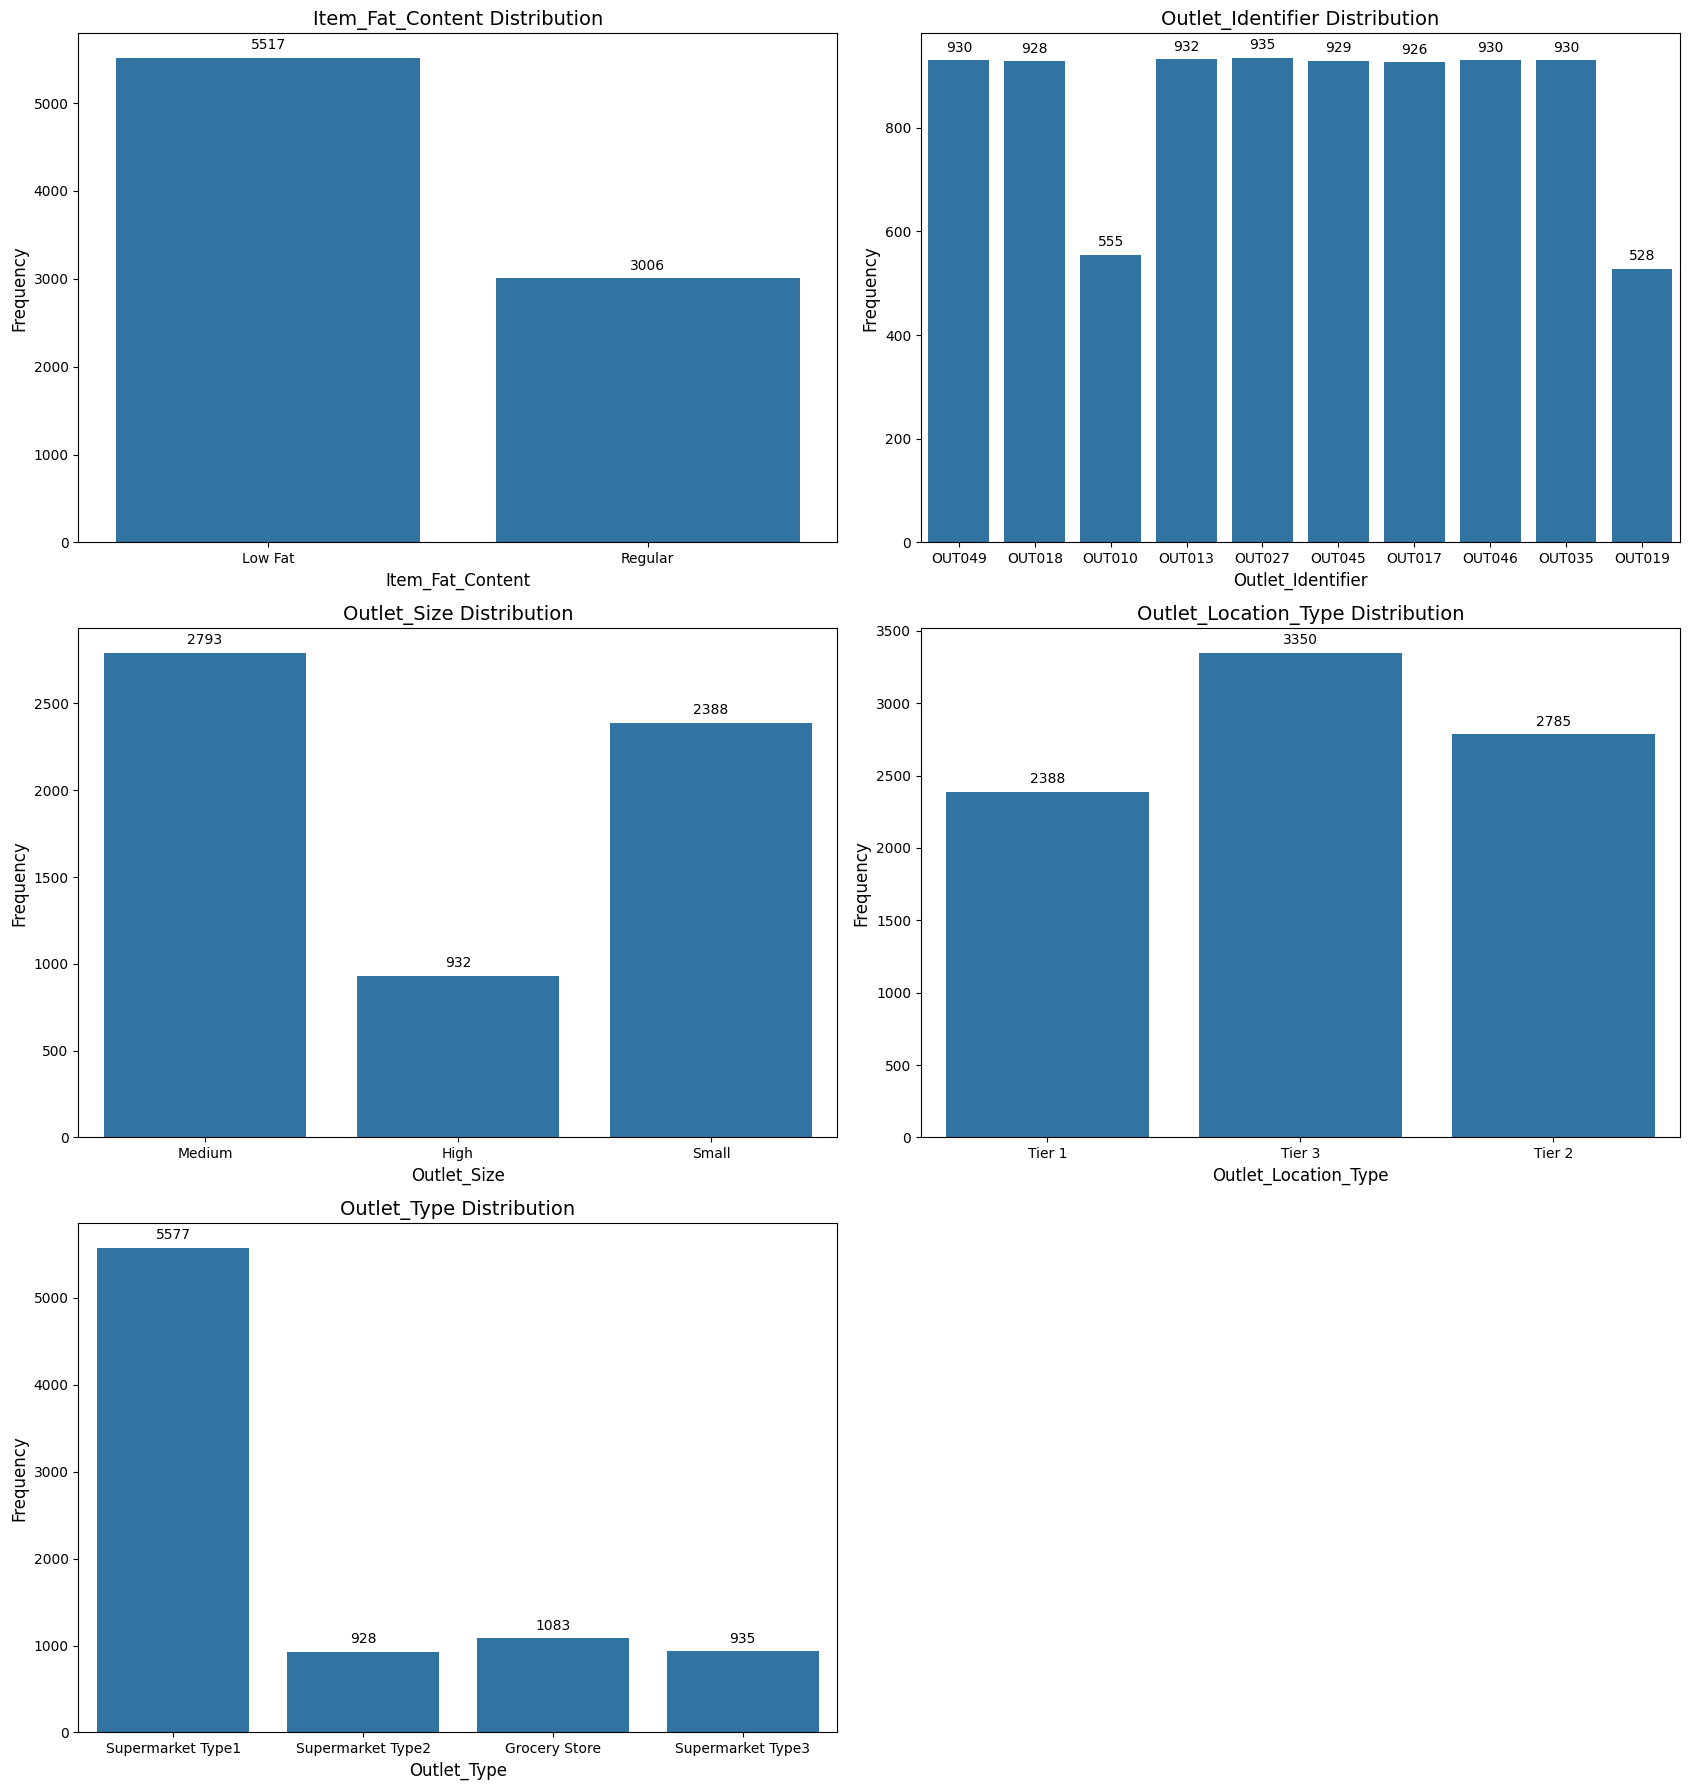

In [18]:
# Create distribution visualization for choosen categorical feature
categorical_feature = ['Item_Fat_Content', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

# Create subplot grid 3x2
fig, axes = plt.subplots(3, 2, figsize=(17,18))
axes = axes.flatten()

# Loop to make every features bar chart
for ax, feature in enumerate(categorical_feature):
    sns.countplot(x=feature, data=df_eda, ax=axes[ax])
    axes[ax].set_title(f'{feature} Distribution', fontsize=14)
    axes[ax].set_xlabel(feature, fontsize=12)
    axes[ax].set_ylabel('Frequency', fontsize=12)

    # Add total label in every bar
    for b in axes[ax].patches:
        axes[ax].annotate(f'{int(b.get_height())}',
                        (b.get_x() + b.get_width() / 2., b.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')
axes[5].remove()

plt.tight_layout()
plt.show()

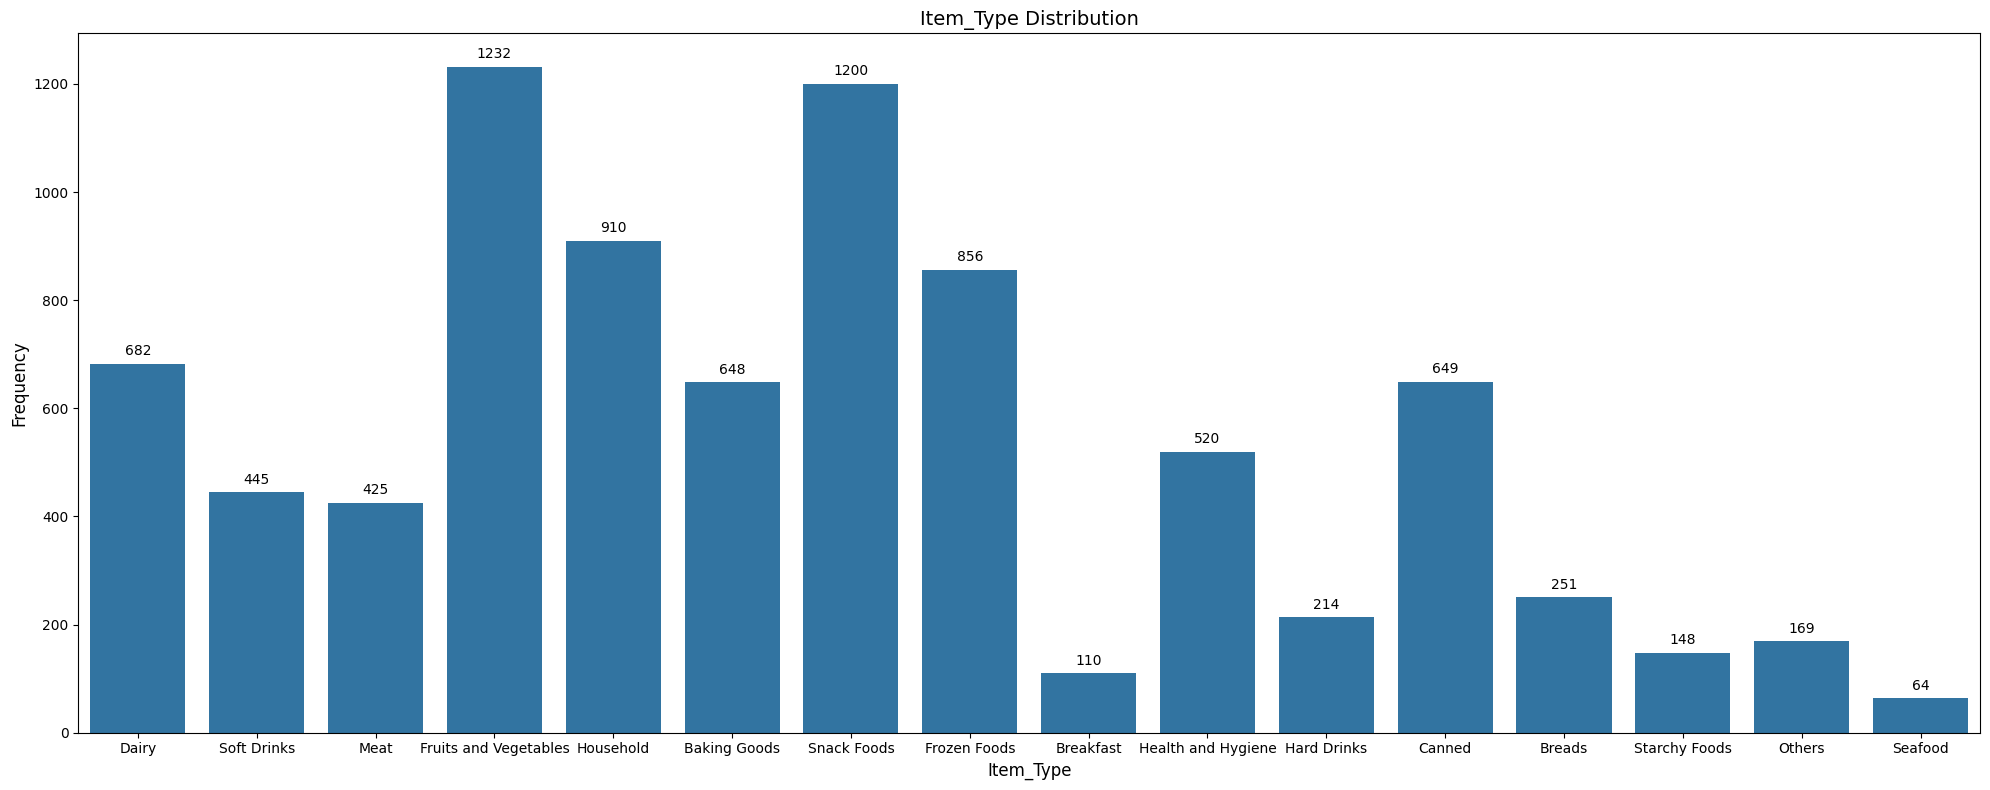

In [19]:
# Create distribution visualization for 'Item_Type'
categorical_feature = 'Item_Type'

# Create subplot grid 1x1
fig, ax = plt.subplots(figsize=(20,8))

# Create bar chart
sns.countplot(x=categorical_feature, data=df_eda, ax=ax)
ax.set_title(f'{categorical_feature} Distribution', fontsize=14)
ax.set_xlabel(categorical_feature, fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Add total label in every bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

#### <center> Bivariate Analysis
##### <center> Numerical Features

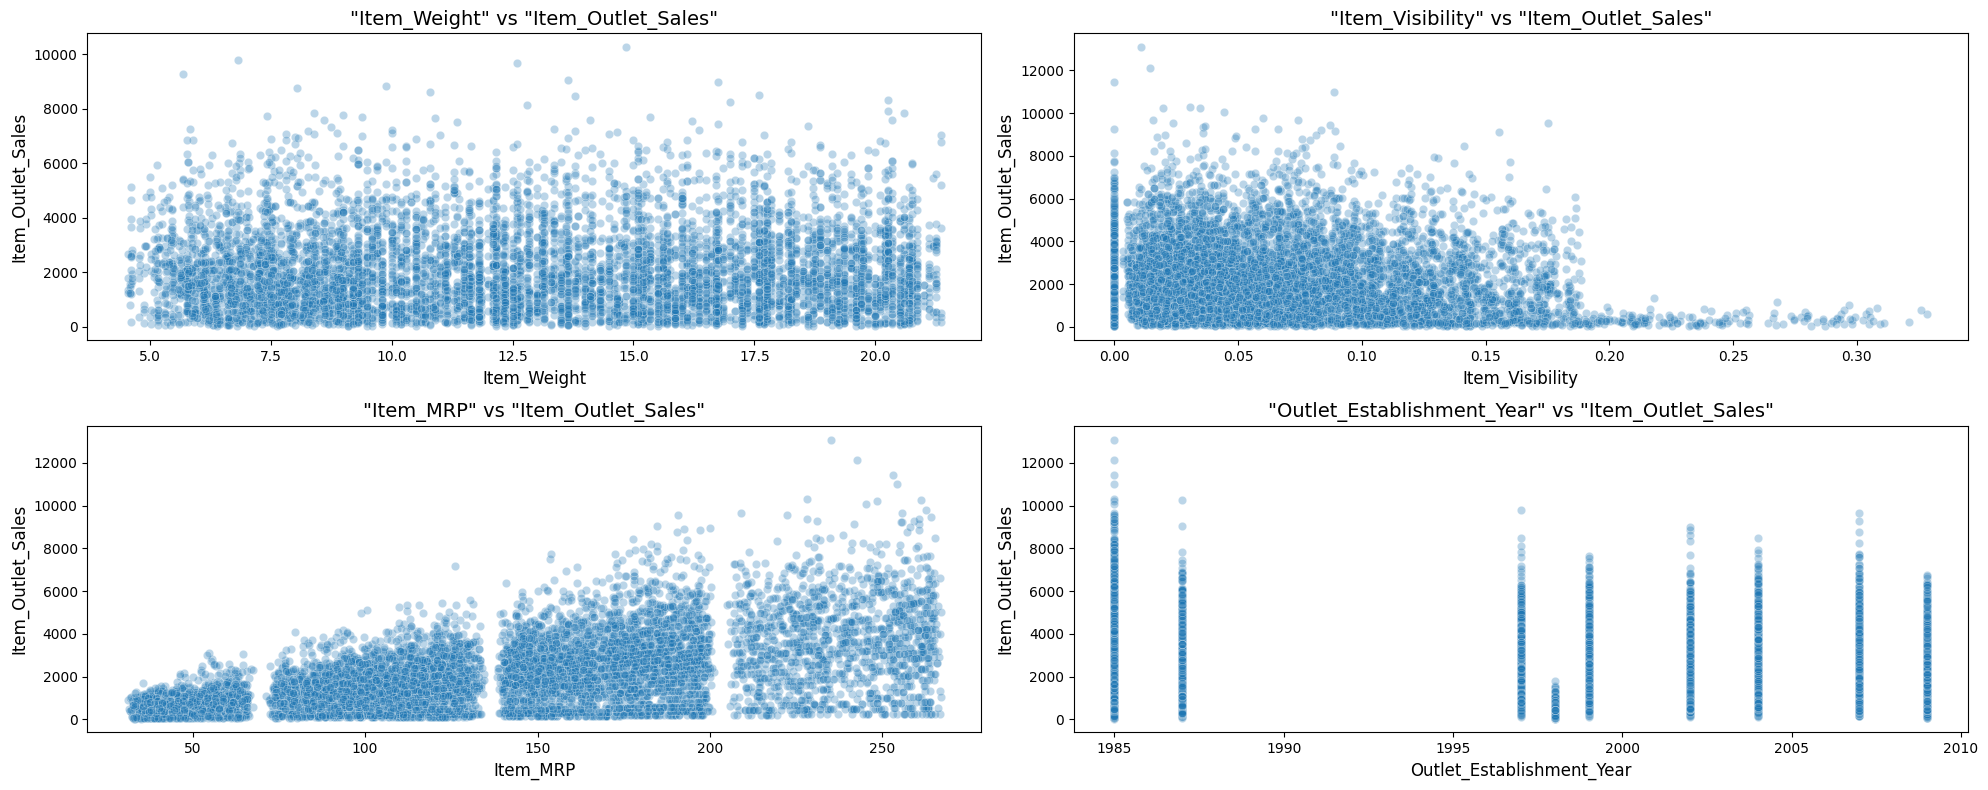

In [20]:
# Scatter plot
numerical_feature = df_eda.drop('Item_Outlet_Sales', axis=1).select_dtypes(include=['int64', 'float64']).columns

# Create subplot grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(20,8))
axes = axes.flatten()

# Create heatmap
for ax, feature in enumerate(numerical_feature):
    sns.scatterplot(data=df_eda, x=feature, y='Item_Outlet_Sales', ax=axes[ax], alpha=0.3)
    axes[ax].set_title(f'"{feature}" vs "Item_Outlet_Sales"', fontsize=14)
    axes[ax].set_xlabel(feature, fontsize=12)
    axes[ax].set_ylabel('Item_Outlet_Sales', fontsize=12)

plt.tight_layout()
plt.show()

##### <center> Categorical Features

In [21]:
# Cross-tabulation
categorical_feature = df_eda.select_dtypes('object').drop('Item_Identifier', axis=1).columns

# Loop to create every categorical features cross tabulation with specific feature
specific_feature = 'Outlet_Location_Type'
for feature in categorical_feature:
    if feature == specific_feature:
        continue
    else:
        print(f'{pd.crosstab(df_eda[feature], df_eda[specific_feature])}\n')

Outlet_Location_Type  Tier 1  Tier 2  Tier 3
Item_Fat_Content                            
Low Fat                 1540    1809    2168
Regular                  848     976    1182

Outlet_Location_Type   Tier 1  Tier 2  Tier 3
Item_Type                                    
Baking Goods              185     211     252
Breads                     67      84     100
Breakfast                  33      32      45
Canned                    177     222     250
Dairy                     205     214     263
Frozen Foods              250     279     327
Fruits and Vegetables     337     399     496
Hard Drinks                58      72      84
Health and Hygiene        138     166     216
Household                 250     296     364
Meat                      123     125     177
Others                     56      52      61
Seafood                    19      22      23
Snack Foods               334     401     465
Soft Drinks               120     157     168
Starchy Foods              36      53

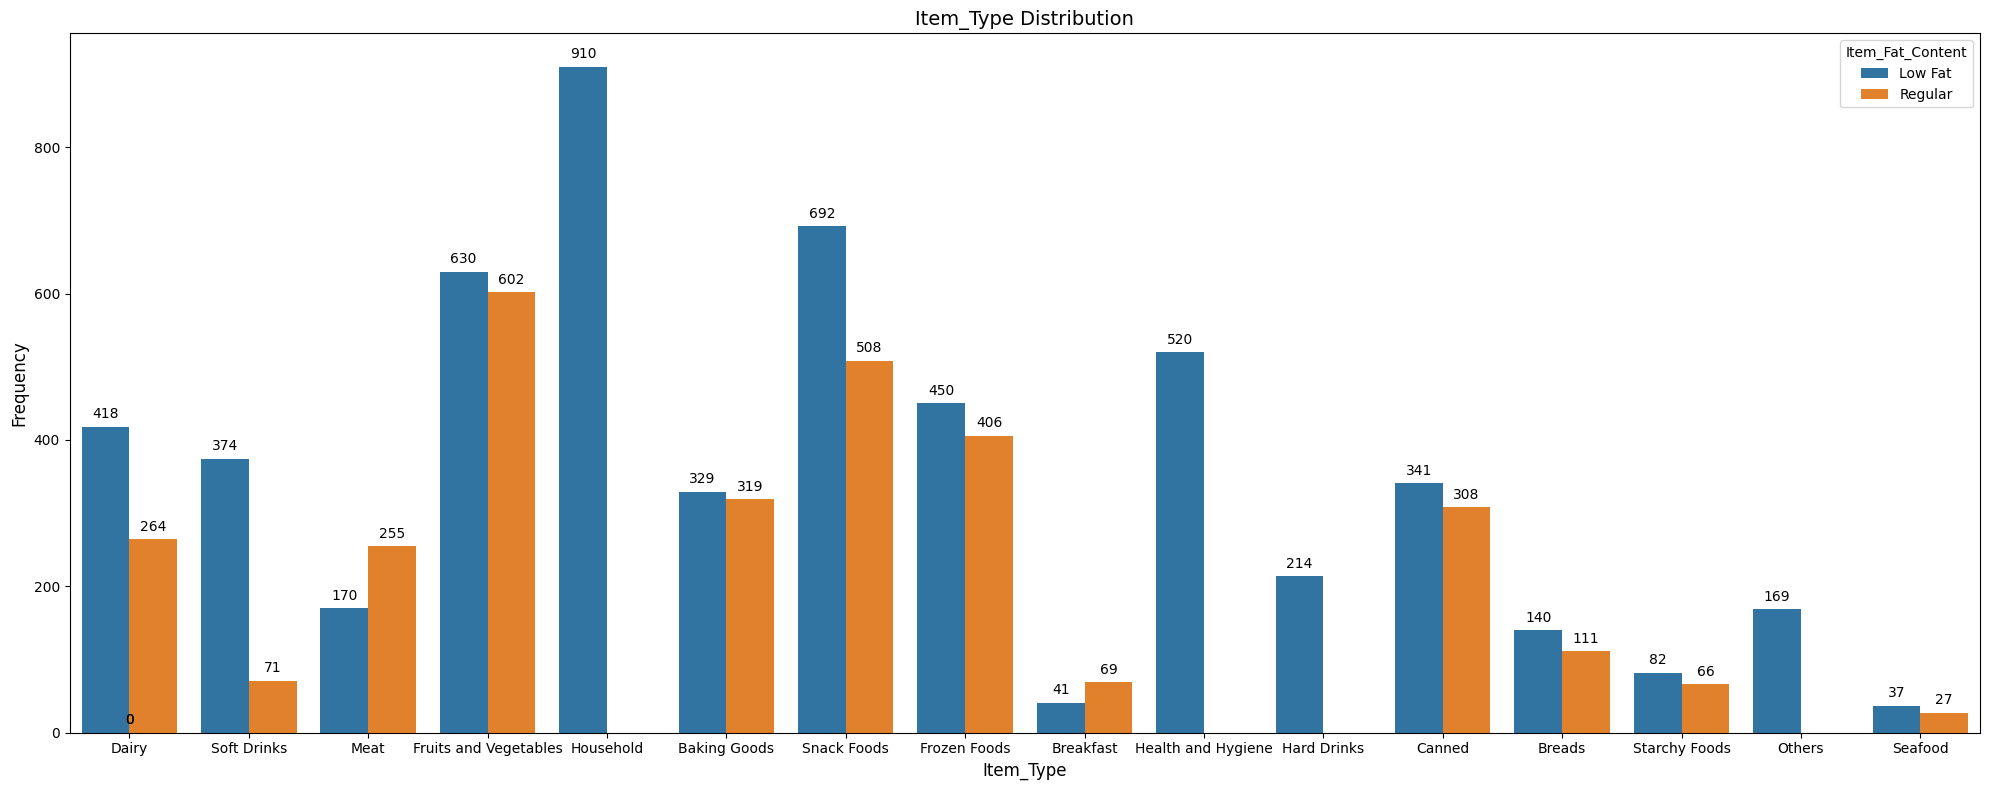

In [22]:
# Grouped Bar Chart for 'Item_Type'
categorical_feature = 'Item_Type'

# Create subplot grid 1x1
fig, ax = plt.subplots(figsize=(20,8))

# Create grouped bar chart
sns.countplot(x=categorical_feature, data=df_eda, hue='Item_Fat_Content', ax=ax)
ax.set_title(f'{categorical_feature} Distribution', fontsize=14)
ax.set_xlabel(categorical_feature, fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Add total label in every bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

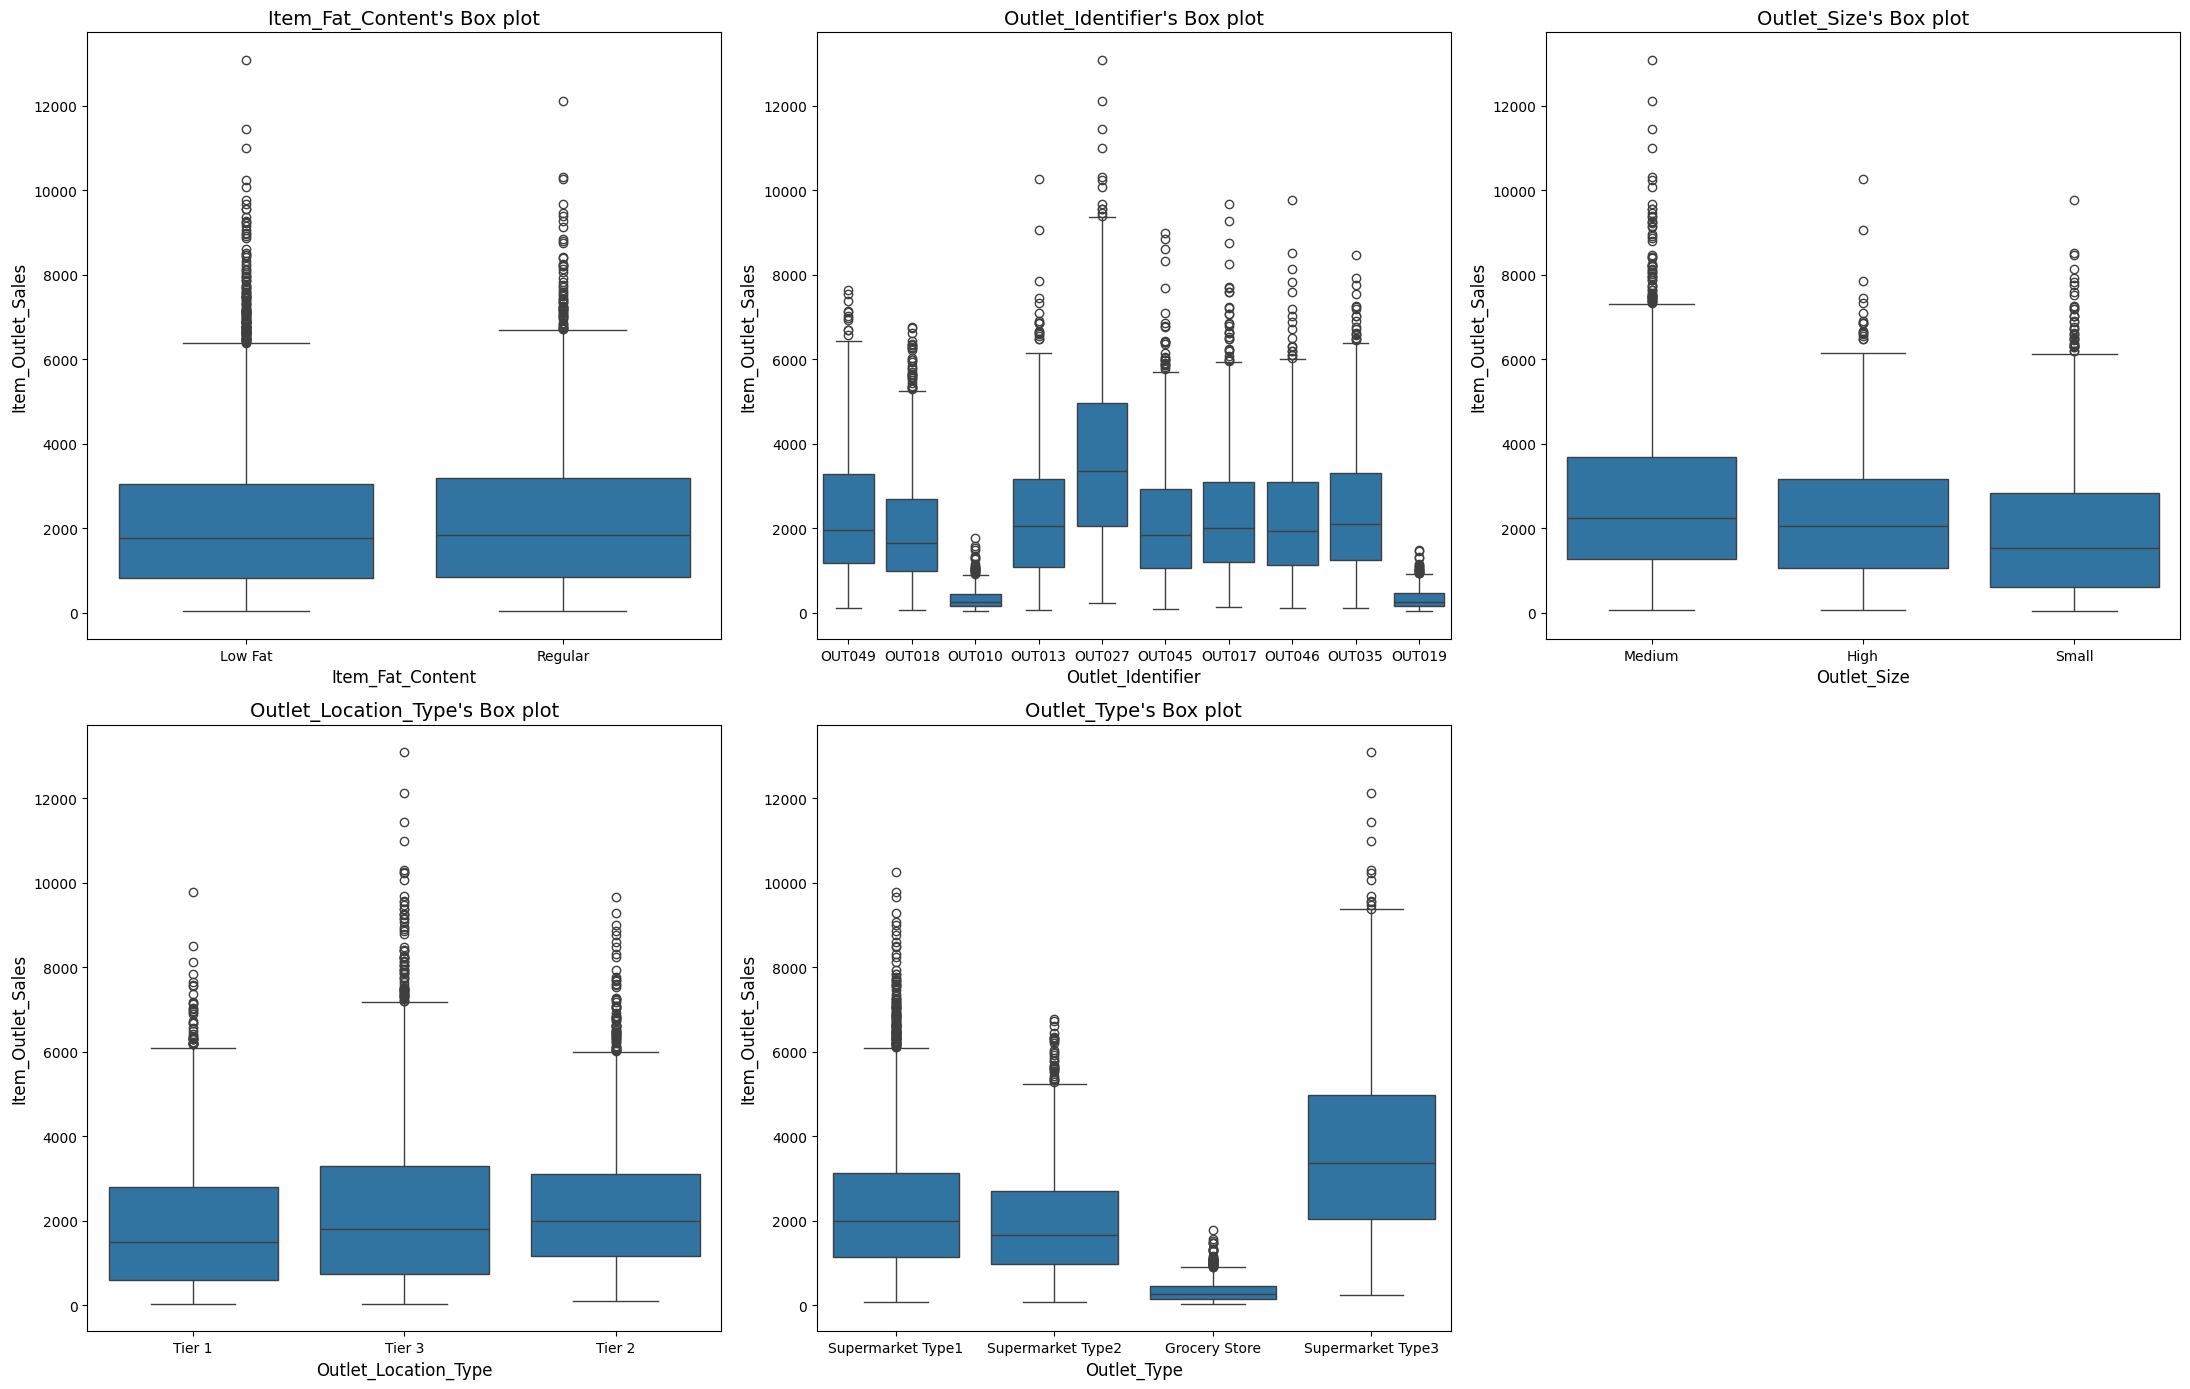

In [23]:
# Boxplot Correlation between chosen categorical features with 'Item_Outlet_Sales'
categorical_feature = ['Item_Fat_Content', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

# Create subplot grid 2x3
fig, axes = plt.subplots(2, 3, figsize=(22,14))
axes = axes.flatten()

# Loop to make every features box plot
for ax, feature in enumerate(categorical_feature):
    sns.boxplot(data=df_eda, x=feature, y='Item_Outlet_Sales', ax=axes[ax])
    axes[ax].set_title(f'{feature}\'s Box plot', fontsize=14)
    axes[ax].set_xlabel(feature, fontsize=12)
    axes[ax].set_ylabel('Item_Outlet_Sales', fontsize=12)
axes[5].remove()

plt.tight_layout()
plt.show()

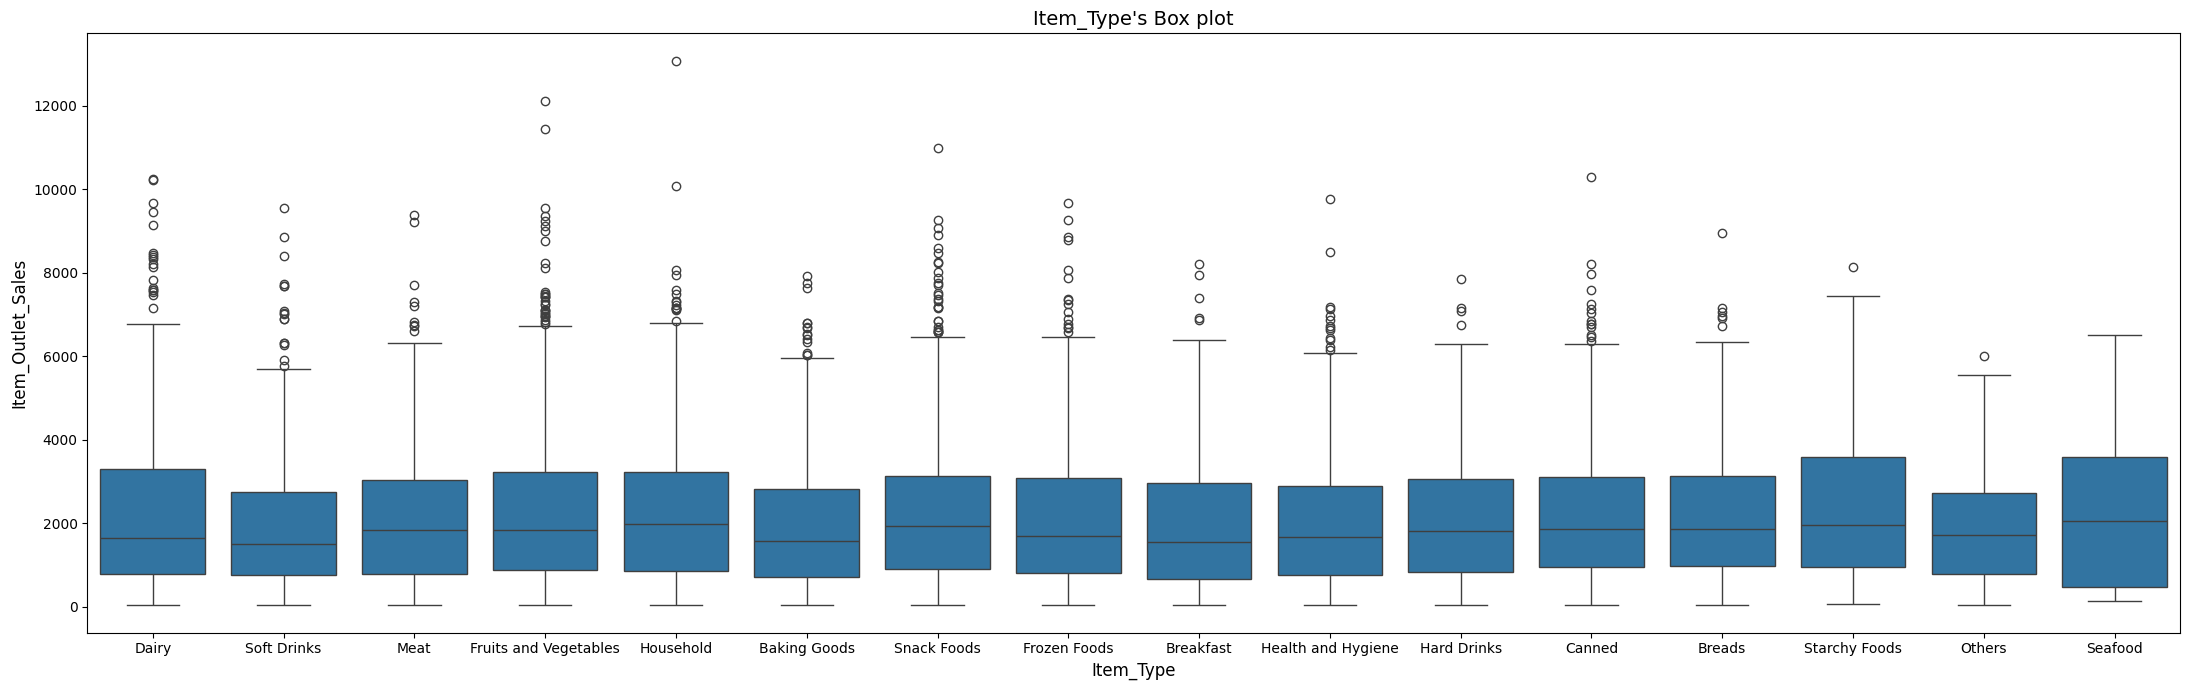

In [24]:
# Boxplot Correlation between the rest chosen categorical features with 'Item_Outlet_Sales'
categorical_feature = 'Item_Type'

# Create subplot grid 1x1
fig, ax = plt.subplots(figsize=(22,7))

# Loop to make every features box plot0
sns.boxplot(data=df_eda, x=categorical_feature, y='Item_Outlet_Sales', ax=ax)
ax.set_title(f'{categorical_feature}\'s Box plot', fontsize=14)
ax.set_xlabel(categorical_feature, fontsize=12)
ax.set_ylabel('Item_Outlet_Sales', fontsize=12)

plt.tight_layout()
plt.show()

#### <center> Multivariate Analysis

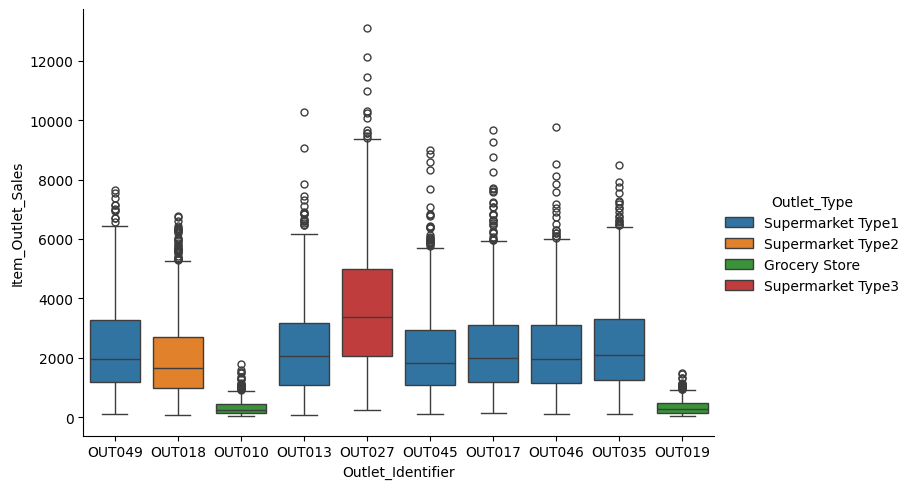

In [25]:
# Categorical Plot
sns.catplot(data=df_eda,
            x="Outlet_Identifier",
            y="Item_Outlet_Sales",
            hue="Outlet_Type",
            kind="box",
            aspect=1.5
            )

plt.show()

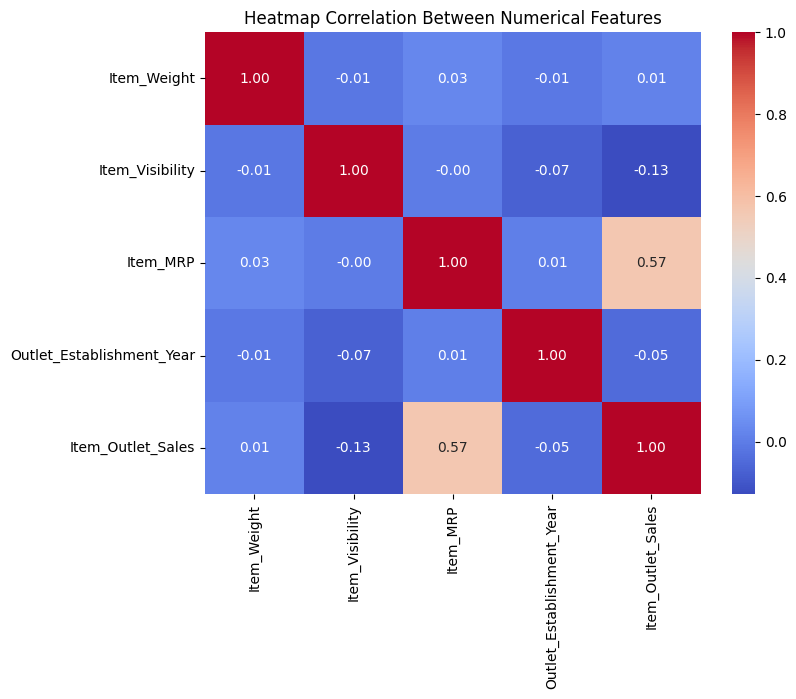

In [26]:
# Heatmap
numerical_feature = df_eda.select_dtypes(include=['int64', 'float64'])

# Create heatmap (Red = Positive Correlation, Blue = Negative Correlation)
correlation_matrix = numerical_feature.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Heatmap Correlation Between Numerical Features')
plt.show()

In [27]:
# # Create Pair Plot to see numerical features correlation + hue on target
# numerical_feature = df_eda.select_dtypes(include=['int64', 'float64']).columns

# # Declare Pair Plot
# pairplot = sns.pairplot(df_eda[numerical_feature], hue='Item_Outlet_Sales', corner=True, palette='coolwarm')
# pairplot.figure.suptitle('Scatter Plot Between Numerical Features', y=1, fontsize=14)

# plt.tight_layout()
# plt.show()

## 📊 Data Preprocessing

In [28]:
# Save the latest dataset into new DataFrame called 'df_process'
df_process = df_eda.copy()

### <center> Data Cleaning
#### <center> 'Item_Weight' Imputation

In [29]:
# Since 'Item_Weight' contain total of 17.17%  missing value, we are gonna impute it
# We can see that 'Item_Weight' value isn't really missing,
# some rows with the same 'Item_Identifier' value (which is the same products) still keep the weight value
df_process[['Item_Identifier', 'Item_Weight']].drop_duplicates().sort_values(by='Item_Identifier').head(10)

,Item_Identifier,Item_Weight
118,DRA12,11.600
2879,DRA24,NaN
1148,DRA24,19.350
6057,DRA59,NaN
1876,DRA59,8.270
3733,DRB01,NaN
3465,DRB01,7.390
1431,DRB13,6.115
2657,DRB24,8.785
776,DRB25,12.300


In [30]:
# Missing value before imputation
print('--- Before Imputation ---')
print(f'[Item_Weight] Missing Value: {df_process['Item_Weight'].isnull().sum()}\n')

# We are gonna impute the missing value on 'Item_Weight' by imputing the same weight on the same 'Item_Identifier'
df_process['Item_Weight'] = df_process.groupby('Item_Identifier')['Item_Weight'].transform('mean')

# Missing value after imputation
print('--- After Imputation ---')
print(f'[Item_Weight] Missing Value: {df_process['Item_Weight'].isnull().sum()}')

--- Before Imputation ---
[Item_Weight] Missing Value: 1463

--- After Imputation ---
[Item_Weight] Missing Value: 4


In [31]:
# Turns out there are still missing values, this time it must be real 'missing'
df_process[df_process['Item_Weight'].isnull()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
927,FDN52,NaN,Regular,0.130933,Frozen Foods,86.9198,OUT027,1985,Medium,Tier 3,Supermarket Type3,1569.9564
1922,FDK57,NaN,Low Fat,0.079904,Snack Foods,120.0440,OUT027,1985,Medium,Tier 3,Supermarket Type3,4434.2280
4187,FDE52,NaN,Regular,0.029742,Dairy,88.9514,OUT027,1985,Medium,Tier 3,Supermarket Type3,3453.5046
5022,FDQ60,NaN,Regular,0.191501,Baking Goods,121.2098,OUT019,1985,Small,Tier 1,Grocery Store,120.5098


In [32]:
# Before we decide between impute by mean or median, we will check is there any outliers first
numerical_feature = ['Item_Weight']

for feature in numerical_feature:
    # Calculate the IQR
    q1 = df_process[feature].quantile(0.25)
    q3 = df_process[feature].quantile(0.75)
    iqr = q3 - q1

    # Set the bound
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    # Check the Outliers
    outliers = df_process[(df_process[feature] < lower_bound) | (df_process[feature] > upper_bound)]
    print(f'[{feature}] total outliers: {len(outliers)}')
    print(f'[{feature}] total outliers (percentage): {(len(outliers)/df_process.shape[0]) * 100:.2f}%\n')

[Item_Weight] total outliers: 0
[Item_Weight] total outliers (percentage): 0.00%



In [33]:
# There are no outliers, so we will impute the remaining missing value by 'Item_Weight' mean
df_process['Item_Weight'] = df_process['Item_Weight'].fillna(df_process['Item_Weight'].mean())

# Missing value after imputation
print('--- After Imputation ---')
print(f'[Item_Weight] Missing Value: {df_process['Item_Weight'].isnull().sum()}')

--- After Imputation ---
[Item_Weight] Missing Value: 0


#### <center> 'Outlet_Size' Imputation

In [34]:
# 'Outlet_Size' contain total of 28.28%  missing value, we are gonna impute it
# Precisely, 'OUT045', 'OUT17', and 'OUT010' that contain no 'Outlet_Size'
# Based on Categorical Plot on Multivariate Analysis (EDA),
# we will impute the missing size by their 'Outlet_Type' mode
print(pd.crosstab(df_process['Outlet_Type'], df_process['Outlet_Size']),'\n')

# Check the missing value 'Outlet_Type'
df_process[['Outlet_Identifier', 'Outlet_Type', 'Outlet_Size']].drop_duplicates()

Outlet_Size        High  Medium  Small
Outlet_Type                           
Grocery Store         0       0    528
Supermarket Type1   932     930   1860
Supermarket Type2     0     928      0
Supermarket Type3     0     935      0 



,Outlet_Identifier,Outlet_Type,Outlet_Size
0,OUT049,Supermarket Type1,Medium
1,OUT018,Supermarket Type2,Medium
3,OUT010,Grocery Store,NaN
4,OUT013,Supermarket Type1,High
7,OUT027,Supermarket Type3,Medium
8,OUT045,Supermarket Type1,NaN
9,OUT017,Supermarket Type1,NaN
11,OUT046,Supermarket Type1,Small
19,OUT035,Supermarket Type1,Small
23,OUT019,Grocery Store,Small


In [35]:
# Missing value before imputation
print('--- Before Imputation ---')
print(f'[Outlet_Size] Missing Value: {df_process['Outlet_Size'].isnull().sum()}\n')

# Based on 'Outlet_Type', all missing values ​​have a mode of 'Small',
# thus we will impute missing value with 'Small'
df_process['Outlet_Size'] = df_process['Outlet_Size'].replace(np.nan, 'Small')

# Missing value after imputation
print('--- After Imputation ---')
print(f'[Outlet_Size] Missing Value: {df_process['Outlet_Size'].isnull().sum()}')

--- Before Imputation ---
[Outlet_Size] Missing Value: 2410

--- After Imputation ---
[Outlet_Size] Missing Value: 0


#### <center> 'Item_Visibility' Anomalies Handling

In [36]:
# We can see that 'Item_Visibility' contain 0 values, weird right?
print(df_process['Item_Visibility'].value_counts().head(5), '\n')

# Check 'Item_Visibility' on another same products based on 'Item_Identifier'
df_process[['Item_Identifier', 'Item_Visibility']].drop_duplicates().sort_values(by='Item_Identifier').head(10)

Item_Visibility
0.000000    526
0.076975      3
0.107274      2
0.074613      2
0.045166      2
Name: count, dtype: int64 



,Item_Identifier,Item_Visibility
1197,DRA12,0.000000
8043,DRA12,0.068535
1245,DRA12,0.040912
118,DRA12,0.041178
7467,DRA12,0.041113
2879,DRA24,0.069909
8195,DRA24,0.039895
4416,DRA24,0.039735
1148,DRA24,0.040154
4900,DRA24,0.039921


In [37]:
# So we are gonna replace them with the same way we impute 'Item_Weight'
df_process['Item_Visibility'] = df_process['Item_Visibility'].mask(
    df_process['Item_Visibility'] == 0,
    df_process.groupby('Item_Identifier')['Item_Visibility'].transform('mean')
)

# Zero value after replace
df_process['Item_Visibility'].value_counts().head(5)

Item_Visibility
0.052234    4
0.017361    3
0.014755    3
0.089296    3
0.046936    3
Name: count, dtype: int64

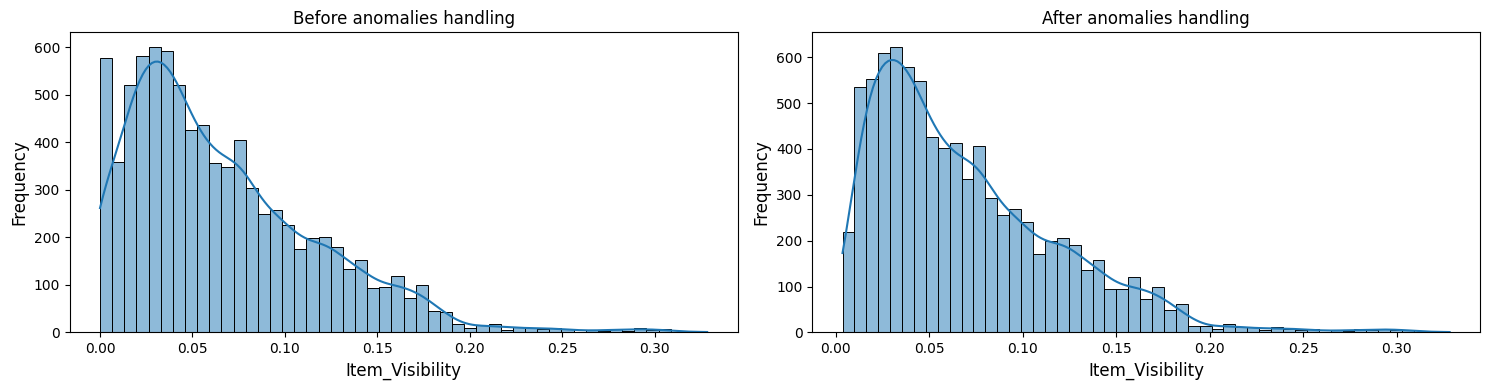

In [38]:
# Create before-after visualization
# Create subplot grid 1x2
fig, axes = plt.subplots(1, 2, figsize=(15,4))

# 'Item_Visibility' distribution before anomalies handling
sns.histplot(data=df_eda, x='Item_Visibility', kde=True, ax=axes[0])
axes[0].set_xlabel('Item_Visibility', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Before anomalies handling')

# 'Item_Visibility' distribution after anomalies handling
sns.histplot(data=df_process, x='Item_Visibility', kde=True, ax=axes[1])
axes[1].set_xlabel('Item_Visibility', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('After anomalies handling')

plt.tight_layout()
plt.show()

### <center> Data Enriching
#### <center> Feature Engineering: 'Outlet_Age'

In [39]:
# We notice that 'Outlet_Establishment_Year' contain valuable information about how old the outlet is
# So we will enrich 'Outlet_Establishment_Year' to get a new feature called 'Outlet_Age'
df_process['Outlet_Age'] = 2013 - df_process['Outlet_Establishment_Year']

# Check the new feature
df_process.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,14
3,FDX07,19.20,Regular,0.015274,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,15
4,NCD19,8.93,Low Fat,0.008082,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,26


#### <center> Feature Engineering: 'Item_Category'

In [40]:
# We will extract information from 'Item_Identifier', we notice that
# every id contain category information for products
# 'FD...' = Food, 'DR...' = Drink, 'NC...' = Non-Consumable

# Extract the first 2 letter on every id
df_process['Item_Category'] = df_process['Item_Identifier'].str[:2]

# Apply mapping
df_process['Item_Category'] = df_process['Item_Category'].map({
    'FD':'Food',
    'DR':'Drink',
    'NC':'Non-Consumable'
})

# Check the new feature
df_process.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,Item_Category
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,14,Food
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,4,Drink
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,14,Food
3,FDX07,19.20,Regular,0.015274,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,15,Food
4,NCD19,8.93,Low Fat,0.008082,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,26,Non-Consumable


#### <center> 'Item_Fat_Content' category renewal

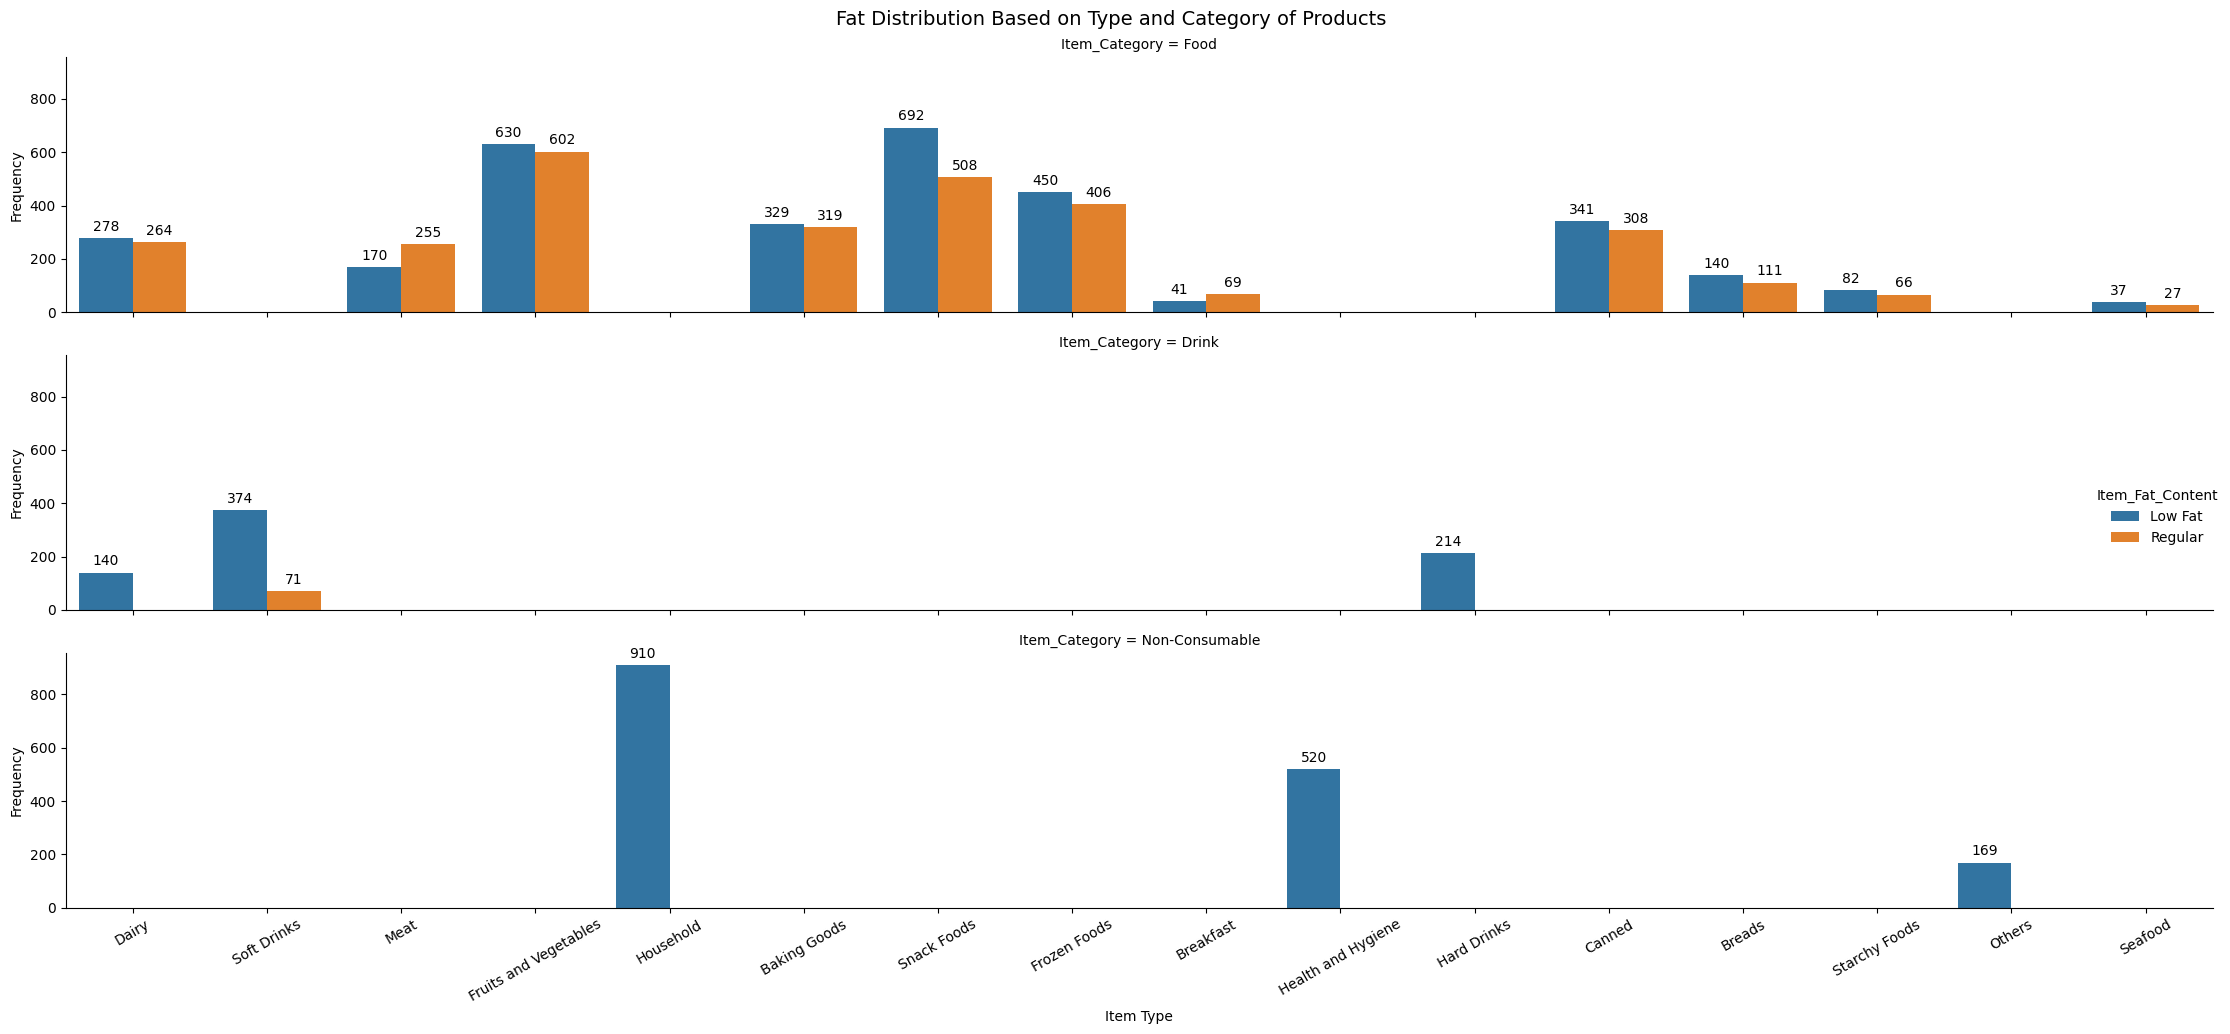

In [41]:
# Categorical Plot
catplot = sns.catplot(data=df_process,
                kind="count",
                x="Item_Type",
                hue="Item_Fat_Content",
                col="Item_Category",
                height=3.5,
                aspect=6,
                col_wrap=1
                )

# Categorical Plot modification
catplot.set_axis_labels("Item Type", "Frequency")
catplot.figure.suptitle('Fat Distribution Based on Type and Category of Products', fontsize=14)
catplot.tick_params(axis='x', rotation=30)

# Add total label in every bar
for ax in catplot.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

In [42]:
# Based on categorical plot above, it tells that products with 'Item_Category' == 'Non-Consumable'
# always contain 'Low Fat' value in 'Item_Fat_Content', we will change this thing by making new category on 'Item_Fat_Content'
df_process[df_process['Item_Category'] == 'Non-Consumable'] = df_process[df_process['Item_Category'] == 'Non-Consumable']\
    .replace('Low Fat', 'Non-Edible')

# Check the DataFrame
df_process['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599
Name: count, dtype: int64

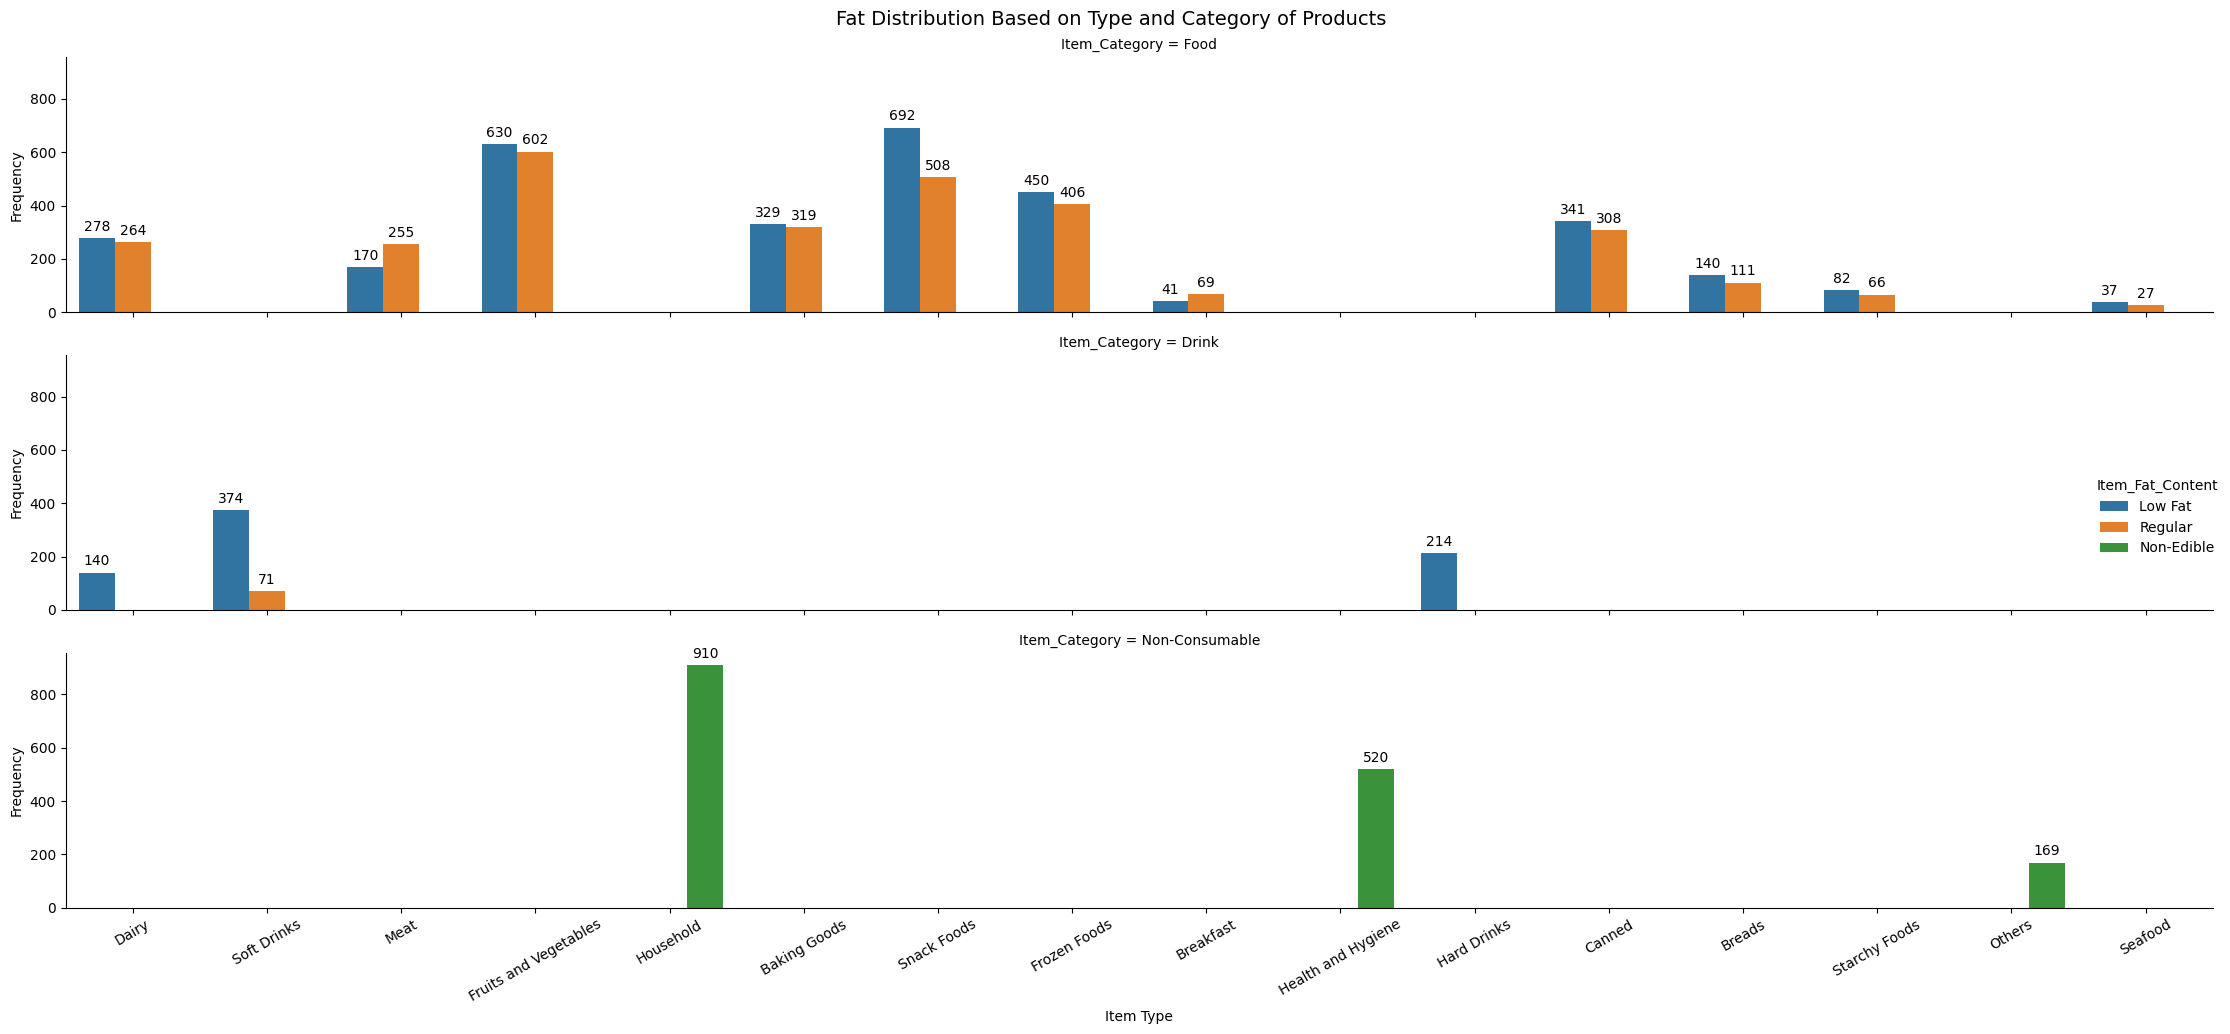

In [43]:
# Categorical Plot after 'Item_Fat_Content' category renewal
catplot = sns.catplot(data=df_process,
                kind="count",
                x="Item_Type",
                hue="Item_Fat_Content",
                col="Item_Category",
                height=3.5,
                aspect=6,
                col_wrap=1
                )

# Categorical Plot modification
catplot.set_axis_labels("Item Type", "Frequency")
catplot.figure.suptitle('Fat Distribution Based on Type and Category of Products', fontsize=14)
catplot.tick_params(axis='x', rotation=30)

# Add total label in every bar
for ax in catplot.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

### <center> Data Transformation
#### <center> 'Item_Visibility' outliers handling

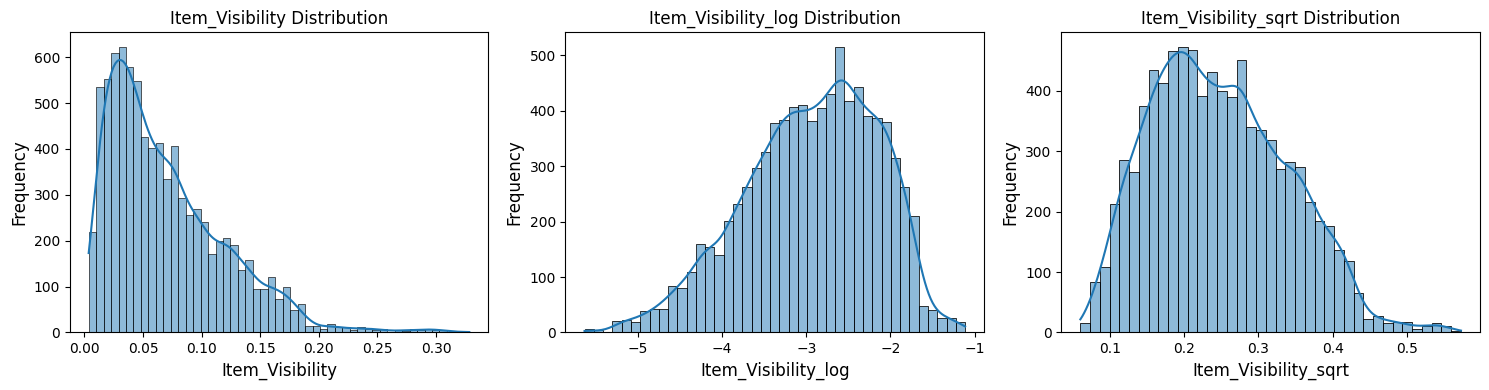

,Skewness,Skewness (Absolute)
Original,1.233077,1.233077
Log,-0.429764,0.429764
Sqrt,0.407829,0.407829


In [44]:
# 'Item_Visibility' contain 1.69% outliers, we will try to apply log and sqrt transform
from scipy.stats import skew

# Create temp Variables
df_temp = df_process.copy()
df_temp['Item_Visibility_log'] = np.log(df_temp['Item_Visibility'])
df_temp['Item_Visibility_sqrt'] = np.sqrt(df_temp['Item_Visibility'])

# Create subplot grid 1x3
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes = axes.flatten()

# Loop to create histogram for 'Item_Visibility'
for ax, feature in enumerate(['Item_Visibility', 'Item_Visibility_log', 'Item_Visibility_sqrt']):
    sns.histplot(data=df_temp, x=feature, kde=True, ax=axes[ax])
    axes[ax].set_xlabel(feature, fontsize=12)
    axes[ax].set_ylabel('Frequency', fontsize=12)
    axes[ax].set_title(f'{feature} Distribution')

plt.tight_layout()
plt.show()

# Calculate Skewness value
results = {}
transforms = {
    'Original': df_temp['Item_Visibility'],
    'Log': df_temp['Item_Visibility_log'],
    'Sqrt': df_temp['Item_Visibility_sqrt']
}

for feature, dataframe in transforms.items():
    skewness = skew(dataframe)

    results[feature] = {
        'Skewness': skewness,
        'Skewness (Absolute)': abs(skewness),
    }

pd.DataFrame(results).T

# We will choose to apply sqrt to 'Item_Visibility' on Pipeline

#### <center> 'Item_Outlet_Sales' outliers handling

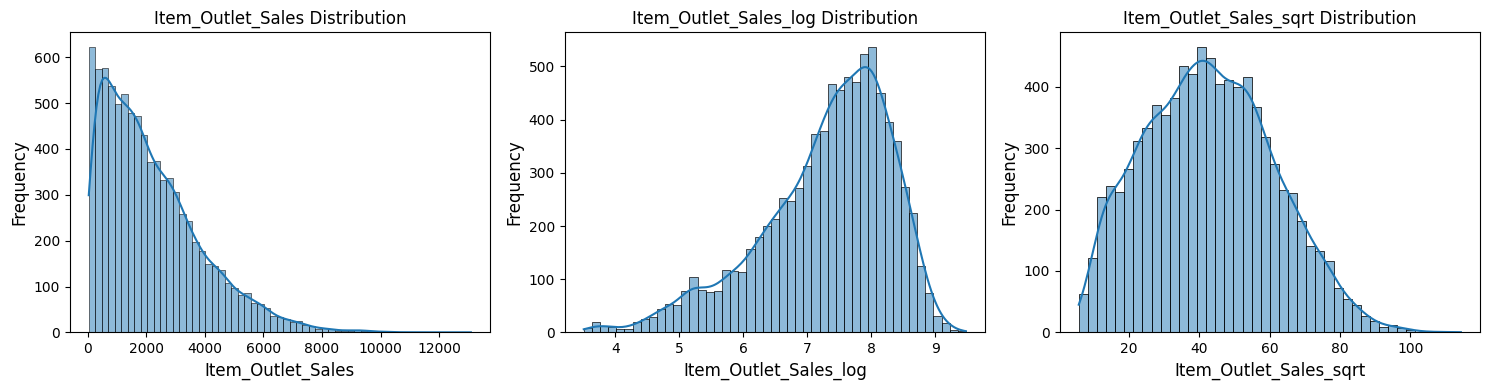

,Skewness,Skewness (Absolute)
Original,1.177323,1.177323
Log,-0.887597,0.887597
Sqrt,0.234635,0.234635


In [45]:
# 'Item_Outlet_Sales' contain 2.18% outliers, we will try to apply log and sqrt transform

# Create temp Variables
df_temp = df_process.copy()
df_temp['Item_Outlet_Sales_log'] = np.log(df_temp['Item_Outlet_Sales'])
df_temp['Item_Outlet_Sales_sqrt'] = np.sqrt(df_temp['Item_Outlet_Sales'])

# Create subplot grid 1x3
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes = axes.flatten()

# Loop to create histogram for 'Item_Visibility'
for ax, feature in enumerate(['Item_Outlet_Sales', 'Item_Outlet_Sales_log', 'Item_Outlet_Sales_sqrt']):
    sns.histplot(data=df_temp, x=feature, kde=True, ax=axes[ax])
    axes[ax].set_xlabel(feature, fontsize=12)
    axes[ax].set_ylabel('Frequency', fontsize=12)
    axes[ax].set_title(f'{feature} Distribution')

plt.tight_layout()
plt.show()

# Calculate Skewness value
results = {}
transforms = {
    'Original': df_temp['Item_Outlet_Sales'],
    'Log': df_temp['Item_Outlet_Sales_log'],
    'Sqrt': df_temp['Item_Outlet_Sales_sqrt']
}

for feature, dataframe in transforms.items():
    skewness = skew(dataframe)

    results[feature] = {
        'Skewness': skewness,
        'Skewness (Absolute)': abs(skewness),
    }

pd.DataFrame(results).T

# We will choose to apply sqrt to 'Item_Outlet_Sales' on Pipeline

#### <center> Ordinal Encoding

In [46]:
# Apply Ordinal Encoding to 'Outlet_Size'
df_process['Outlet_Size'] = df_process['Outlet_Size'].map({'Small':0, 'Medium':1, 'High':2})

# Check DataFrame
print(df_process['Outlet_Size'].value_counts())
df_process['Outlet_Size'].head()

Outlet_Size
0    4798
1    2793
2     932
Name: count, dtype: int64


0    1
1    1
2    1
3    0
4    2
Name: Outlet_Size, dtype: int64

#### <center> One-Hot Encoding

In [47]:
# Apply One-Hot Encoding to 'Item_Fat_Content', 'Outlet_Identifier', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category'
df_process = pd.get_dummies(
    df_process,
    columns=['Item_Fat_Content', 'Outlet_Identifier', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category'],
    prefix=['Item_Fat_Content', 'Outlet_Identifier', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category'],
    drop_first=True,
    dtype=int
)

# Check DataFrame
print(df_process.info(), '\n')
df_process.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Item_Identifier                8523 non-null   object 
 1   Item_Weight                    8523 non-null   float64
 2   Item_Visibility                8523 non-null   float64
 3   Item_Type                      8523 non-null   object 
 4   Item_MRP                       8523 non-null   float64
 5   Outlet_Establishment_Year      8523 non-null   int64  
 6   Outlet_Size                    8523 non-null   int64  
 7   Item_Outlet_Sales              8523 non-null   float64
 8   Outlet_Age                     8523 non-null   int64  
 9   Item_Fat_Content_Non-Edible    8523 non-null   int64  
 10  Item_Fat_Content_Regular       8523 non-null   int64  
 11  Outlet_Identifier_OUT013       8523 non-null   int64  
 12  Outlet_Identifier_OUT017       8523 non-null   i

,Item_Identifier,Item_Weight,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Item_Outlet_Sales,Outlet_Age,Item_Fat_Content_Non-Edible,Item_Fat_Content_Regular,Outlet_Identifier_OUT013,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3,Item_Category_Food,Item_Category_Non-Consumable
0,FDA15,9.30,0.016047,Dairy,249.8092,1999,1,3735.1380,14,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0
1,DRC01,5.92,0.019278,Soft Drinks,48.2692,2009,1,443.4228,4,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0
2,FDN15,17.50,0.016760,Meat,141.6180,1999,1,2097.2700,14,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0
3,FDX07,19.20,0.015274,Fruits and Vegetables,182.0950,1998,0,732.3800,15,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,NCD19,8.93,0.008082,Household,53.8614,1987,2,994.7052,26,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1


### <center> Data Reduction

In [48]:
# Delete unused features
df_process = df_process.drop(['Item_Identifier', 'Item_Type', 'Outlet_Establishment_Year'], axis=1)

# Check the DataFrame
print(df_process.info(), '\n')
df_process.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Item_Weight                    8523 non-null   float64
 1   Item_Visibility                8523 non-null   float64
 2   Item_MRP                       8523 non-null   float64
 3   Outlet_Size                    8523 non-null   int64  
 4   Item_Outlet_Sales              8523 non-null   float64
 5   Outlet_Age                     8523 non-null   int64  
 6   Item_Fat_Content_Non-Edible    8523 non-null   int64  
 7   Item_Fat_Content_Regular       8523 non-null   int64  
 8   Outlet_Identifier_OUT013       8523 non-null   int64  
 9   Outlet_Identifier_OUT017       8523 non-null   int64  
 10  Outlet_Identifier_OUT018       8523 non-null   int64  
 11  Outlet_Identifier_OUT019       8523 non-null   int64  
 12  Outlet_Identifier_OUT027       8523 non-null   i

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Size,Item_Outlet_Sales,Outlet_Age,Item_Fat_Content_Non-Edible,Item_Fat_Content_Regular,Outlet_Identifier_OUT013,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3,Item_Category_Food,Item_Category_Non-Consumable
0,9.30,0.016047,249.8092,1,3735.1380,14,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0
1,5.92,0.019278,48.2692,1,443.4228,4,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0
2,17.50,0.016760,141.6180,1,2097.2700,14,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0
3,19.20,0.015274,182.0950,0,732.3800,15,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,8.93,0.008082,53.8614,2,994.7052,26,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1


### <center> Preparation Before Modelling

In [49]:
# Tidy up dataset for modelling
final_feature = [
                'Item_MRP',                                    # 0
                'Item_Weight',                                 # 1
                'Item_Visibility',                             # 2
                'Outlet_Age',                                  # 3
                'Outlet_Size',                                 # 4
                'Item_Fat_Content_Non-Edible',                 # 5
                'Item_Fat_Content_Regular',                    # 6
                'Item_Category_Food',                          # 7
                'Item_Category_Non-Consumable',                # 8
                'Outlet_Location_Type_Tier 2',                 # 9
                'Outlet_Location_Type_Tier 3',                 # 10
                'Outlet_Type_Supermarket Type1',               # 11
                'Outlet_Type_Supermarket Type2',               # 12
                'Outlet_Type_Supermarket Type3',               # 13
                'Outlet_Identifier_OUT013',                    # 14
                'Outlet_Identifier_OUT017',                    # 15
                'Outlet_Identifier_OUT018',                    # 16
                'Outlet_Identifier_OUT019',                    # 17
                'Outlet_Identifier_OUT027',                    # 18
                'Outlet_Identifier_OUT035',                    # 19
                'Outlet_Identifier_OUT045',                    # 20
                'Outlet_Identifier_OUT046',                    # 21
                'Outlet_Identifier_OUT049',                    # 22
                'Item_Outlet_Sales'                            # 23
                ]
df_final = df_process[final_feature]

# Check DataFrame final
print(f'Final DataFrame (df_final):\n{'='*27}\n')
df_final.info()

Final DataFrame (df_final):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Item_MRP                       8523 non-null   float64
 1   Item_Weight                    8523 non-null   float64
 2   Item_Visibility                8523 non-null   float64
 3   Outlet_Age                     8523 non-null   int64  
 4   Outlet_Size                    8523 non-null   int64  
 5   Item_Fat_Content_Non-Edible    8523 non-null   int64  
 6   Item_Fat_Content_Regular       8523 non-null   int64  
 7   Item_Category_Food             8523 non-null   int64  
 8   Item_Category_Non-Consumable   8523 non-null   int64  
 9   Outlet_Location_Type_Tier 2    8523 non-null   int64  
 10  Outlet_Location_Type_Tier 3    8523 non-null   int64  
 11  Outlet_Type_Supermarket Type1  8523 non-null   int64  
 12  Outlet_Type_Superma

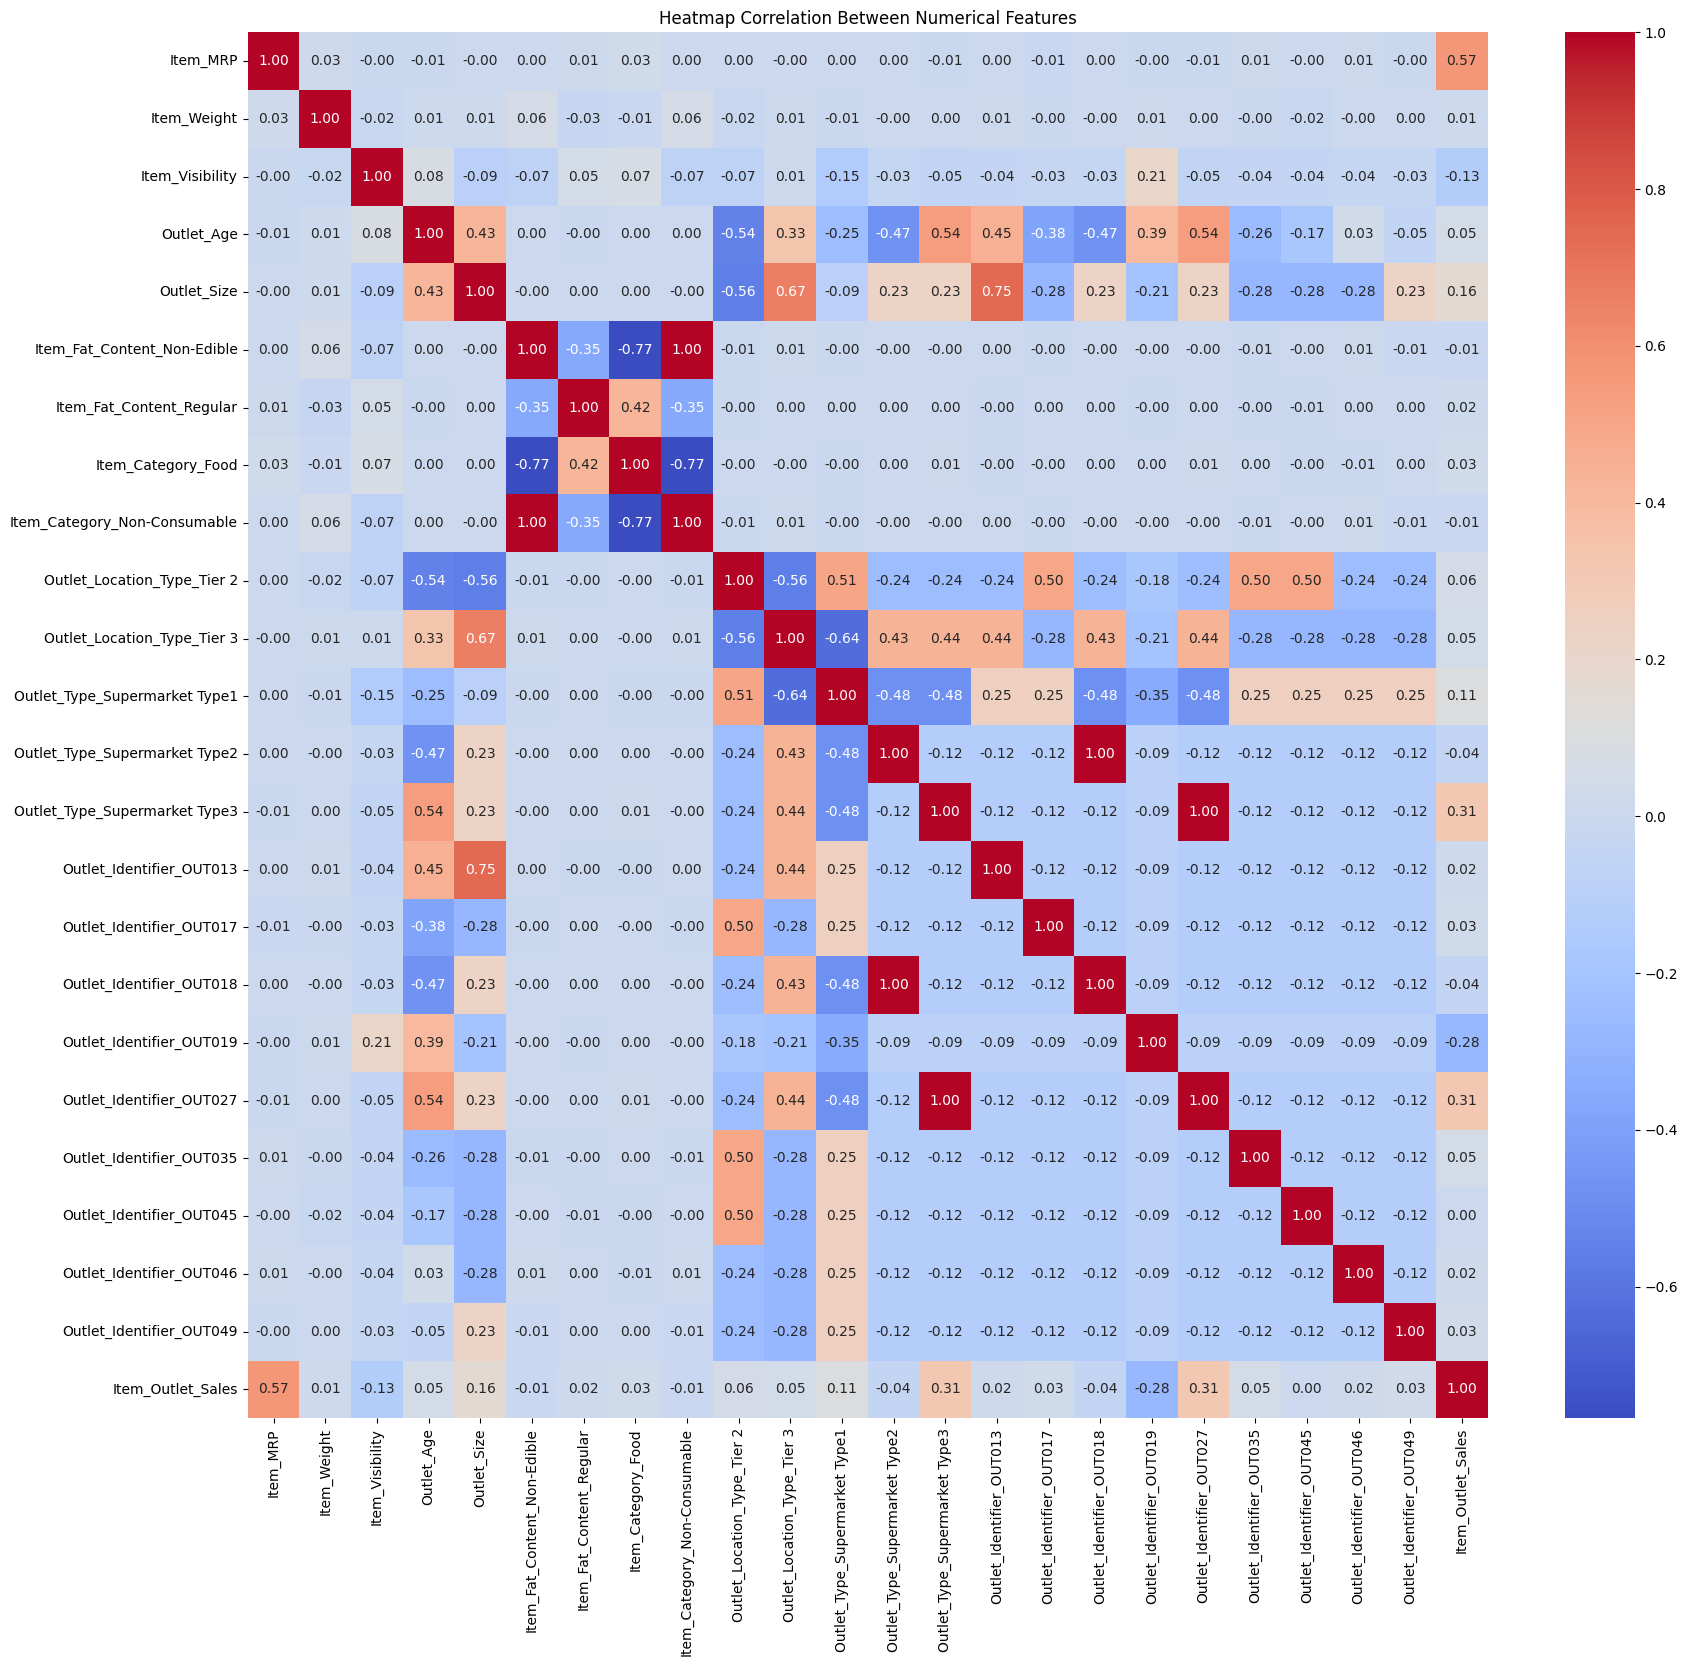

In [50]:
# Create heatmap (Red = Positive Correlation, Blue = Negative Correlation)
correlation_matrix = df_final.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Heatmap Correlation Between Numerical Features')
plt.show()

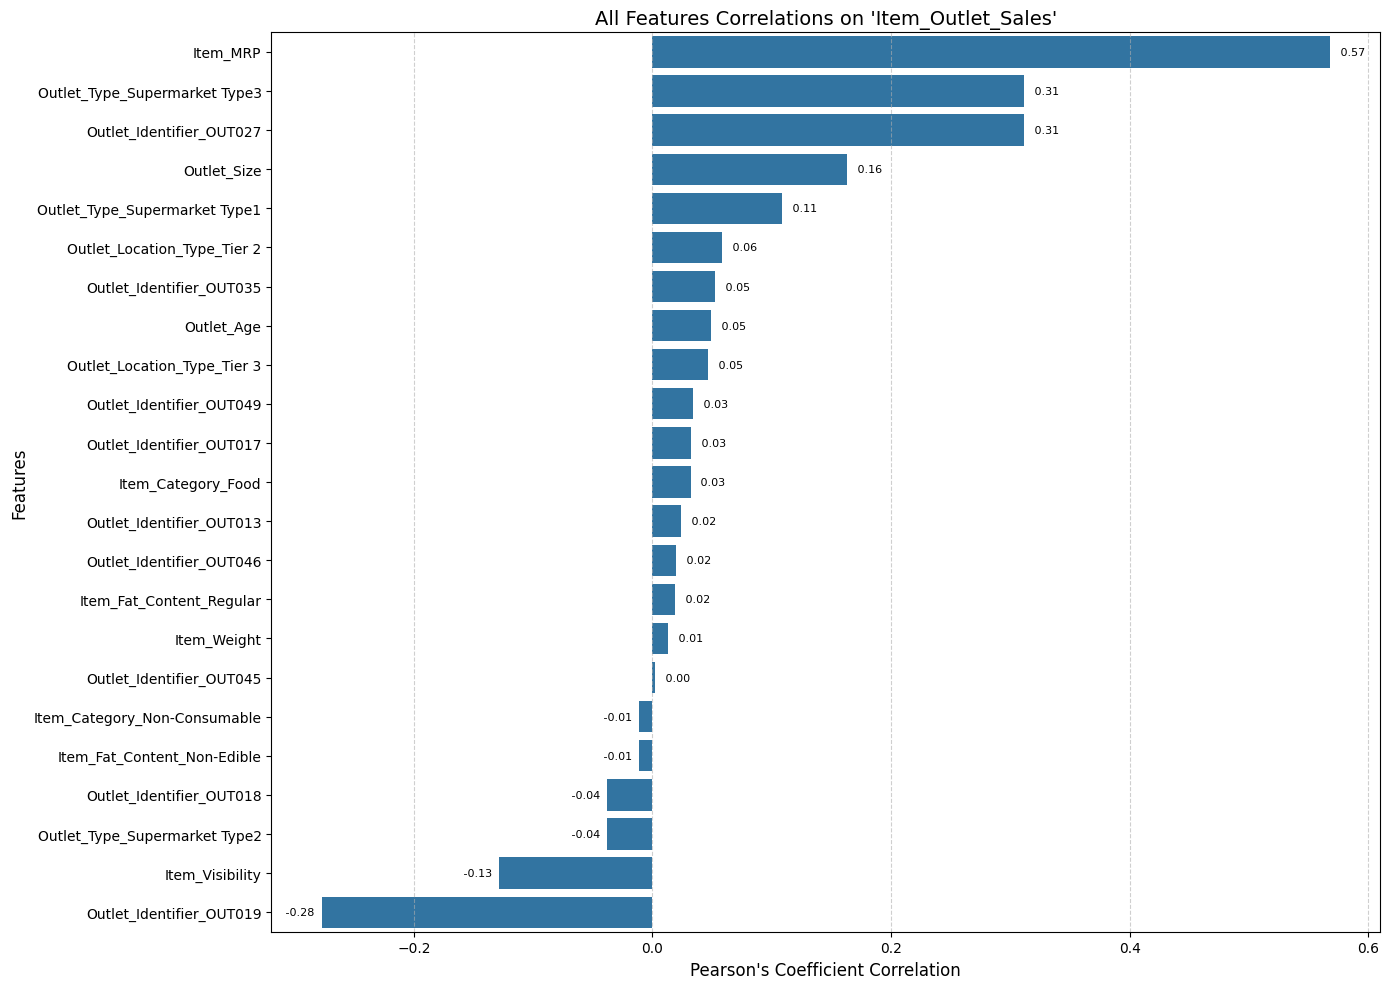

In [51]:
# Calculate correlation of all features from df_final against 'Item_Outlet_Sales'
correlations = df_final.corr()['Item_Outlet_Sales'].sort_values(ascending=False).drop('Item_Outlet_Sales')

# Create visualization
fig, ax = plt.subplots(figsize=(14, 10))

sns.barplot(x=correlations.values, y=correlations.index, ax=ax)
ax.set_title('All Features Correlations on \'Item_Outlet_Sales\'', fontsize=14)
ax.set_xlabel('Pearson\'s Coefficient Correlation', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Add total label in every bar
for bar in ax.patches:
    value = bar.get_width()
    xy = (value, bar.get_y() + bar.get_height() / 2)
    xytext = (5 if value >= 0 else -5, 0)
    ha = 'left' if value >= 0 else 'right'

    ax.annotate(
        f' {value:.2f}',
        xy=xy,
        xytext=xytext,
        textcoords='offset points',
        va='center',
        ha=ha,
        fontsize=8
    )

plt.tight_layout()
plt.show()

## 🧮 Model Training

In [52]:
# Import important library
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline

# Import Regression Model
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

#-------------------------------------------------------------------------------
# STEP 0: PREPARE THE DATA
#-------------------------------------------------------------------------------

# Features we choose to transform + scale
feature_transform_scale = [
    'Item_Visibility'
]

# Features we choose only to scale
feature_scale = [
    'Item_MRP',
    'Item_Weight',
    'Outlet_Age'
]

# Declare Models
models =  {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Lasso Regression": Lasso(random_state=42, alpha=0.1),
    "Elastic Net": ElasticNet(random_state=42, alpha=0.1, l1_ratio=0.5),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
}

# Split Features (X) and Target (y)
X = df_final.drop(['Item_Outlet_Sales'], axis=1)
y = df_final['Item_Outlet_Sales']

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#-------------------------------------------------------------------------------
# STEP 1: MODEL AND PROCESSOR
#-------------------------------------------------------------------------------

# Feature preprocessing (transform, scale)
preprocessing = ColumnTransformer(
    transformers=[
        ('transform_scale', Pipeline(
            steps=[
                ('transform', FunctionTransformer(np.sqrt)),
                ('scale', StandardScaler())
            ]
        ), feature_transform_scale),

        ('scale', StandardScaler(), feature_scale)
    ],
    remainder='passthrough'
)

for model_name, model in models.items():
    # Combine preprocessing and model
    pipeline = Pipeline(
        steps=[
            ('preprocessing', preprocessing),
            ('model', model)
        ]
    )

    # Transform the target (y)
    pipeline_transformed = TransformedTargetRegressor(
        regressor=pipeline,
        func=np.sqrt,
        inverse_func=np.square
    )

    # Calculate the cross-validation scores
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline_transformed, X_train, y_train, cv=kf, scoring ='r2')

    # Check the results
    print(f'Cross-Validation results for: {model_name}')
    print(f'{'='*48}\nScores: {cv_scores}')
    print(f'Average Score: {cv_scores.mean()}')
    print(f'Score\'s std: {cv_scores.std()}\n')

Cross-Validation results for: Linear Regression
Scores: [0.56539744 0.588188   0.56234242 0.59257245 0.58683946]
Average Score: 0.579067952711402
Score's std: 0.012590229118420868

Cross-Validation results for: Ridge Regression
Scores: [0.56525708 0.58808278 0.5623083  0.59247373 0.58664869]
Average Score: 0.5789541140884495
Score's std: 0.012569891599561523

Cross-Validation results for: Lasso Regression
Scores: [0.55639449 0.58074425 0.55738601 0.58734383 0.57723377]
Average Score: 0.5718204685739281
Score's std: 0.012619244719506916

Cross-Validation results for: Elastic Net
Scores: [0.51420495 0.54076734 0.52798105 0.54653652 0.52609929]
Average Score: 0.531117830959273
Score's std: 0.011418577834439888

Cross-Validation results for: Random Forest
Scores: [0.52091283 0.53053729 0.51262253 0.56361661 0.5577451 ]
Average Score: 0.5370868734588499
Score's std: 0.020167251794092945

Cross-Validation results for: XGBoost
Scores: [0.50711653 0.4985973  0.48325583 0.53531545 0.52659485]
A

## ✅ Model Evaluation

## 🌐 Deployment

## 📝 Things After Everything